# Task 1 – Data Understanding and Preparation

## Objective
Build a reliable analytical dataset by integrating artist-level and track-level data, validating data quality, engineering interpretable features, and identifying non-redundant variables for downstream modeling.

## Task 1 Workflow Summary

### Phase 1: Data Ingestion and Merge Validation
Load the two source datasets and verify a correct one-to-many merge between artists and tracks.

**Key actions:**
- Load `artists.csv` (semicolon-separated) and `tracks.csv` (comma-separated)
- Merge on artist identifier with one-to-many validation
- Check coverage and cardinality consistency

**Checks performed:**
- Number of rows and features before/after merge
- Unique artists and songs preserved
- Merge coverage percentage against original tracks table

### Phase 2: Schema Understanding and Semantic Grouping
Map variables to semantic families to make EDA and feature decisions traceable.

**Key actions:**
- Build feature group table by level and domain
- Summarize number of variables per group
- Keep engineered feature documentation table for reproducibility

### Phase 3: Text Redundancy Resolution
Detect near-duplicate text fields and retain the most informative representation.

**Decisions taken:**
- Drop `album`, keep `album_name` (lower missingness)
- Drop `title`, keep `full_title` (richer context)

**Method:**
- Pairwise text similarity comparison over non-null overlaps
- Decision table with motivation for each dropped column

### Phase 4: Cleaning, Typing, and Date Construction
Standardize values and enforce consistent datatypes to avoid downstream leakage and parsing errors.

**Key actions:**
- Convert numeric columns with coercion on invalid values
- Parse date columns (`birth_date`, `active_start`, `active_end`, `album_release_date`)
- Normalize `explicit` and derive numeric version
- Build `track_release_date` from year/month/day
- Derive robust `release_year` from track date with album-date fallback

### Phase 5: Data Quality Diagnostics
Assess missingness, duplicates, invalid values, and out-of-domain observations.

**Quality checks performed:**
- Missing values by feature and by semantic group
- Duplicate song IDs, duplicate rows, duplicate artist-title pairs
- Artist name inconsistencies
- Invalid or implausible dates
- Domain-rule violations (e.g., popularity bounds, bpm and duration limits)
- Robust outlier summaries using statistical and rule-based criteria

### Phase 6: Data Transformation and Feature Engineering
Improve data quality and create interpretable features aligned with project goals and ready for modeling.

**Data transformations include:**
- Log transformation of skewed numeric features ('statpageviews')
- Creation of numeric explicit content indicator from binary `explicit` field
- Normalization


**Engineered features include:**
- `swear_total`, `swear_density_total`
- `artist_macroarea`
- `sentence_complexity_index`
- `artist_song_count`
- `audio_signature_score`
- `release_recency_years`
- `engagement_ratio`
- `explicit_content_intensity`
- `artist_consistency_score`
- `lyric_audio_balance`
- `artist_geographic_diversity`
- `mood_label` (valence-arousal MER-inspired proxy)

### Phase 7: Exploratory Analysis and Interpretability
Analyze distributions and key relationships to ground model choices.

**Exploration performed:**
- Histograms, boxplots, and violin plots for core variables
- Log-transformed inspection for skewed distributions
- Regional comparison of profanity density
- Geographic diversity analysis at artist level
- Mood-label profiling versus swear density and geographic deviation

### Phase 8: Correlation and Redundancy Reduction
Identify multicollinearity and select a compact feature subset for modeling.

**Method:**
- Pearson and Spearman correlation matrices
- High-correlation pair extraction
- Correlation-group discovery and scoring-based selection
- Keep anchor feature per group, optionally keep one secondary if signal is distinct

**Output:**
- Group-level keep/drop decisions with documented rationale
- Final selected feature subset for next tasks

---

## Task 1 Deliverables

- Merged and cleaned working dataframe
- Data quality diagnostics tables (missingness, duplicates, outliers, invalid dates)
- Engineered feature set with motivations
- EDA visual outputs and interpretation notes
- Correlation-aware non-redundant feature subset for modeling

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import colors as mcolors
from IPython.display import display

#%load_ext autoreload # Automatically reloads user-defined functions when they change
#%autoreload 2

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)
sns.set_theme(style="whitegrid", context="talk")

candidate_dirs = [Path.cwd().parent / "dataset", Path.cwd() / "dataset"]
DATA_DIR = next((path for path in candidate_dirs if (path / "artists.csv").exists() and (path / "tracks.csv").exists()), None)
if DATA_DIR is None:
    raise FileNotFoundError("Could not locate the repo-level dataset/ directory.")

print(f"Using data directory: {DATA_DIR.resolve()}")


Using data directory: /home/giuseppebasile/Materiale_Accademico/SNS/Intro_to_ML/First Project/dataset


## Load The Raw Datasets

**Datasets:**
- `artists.csv`: Artist-level metadata (semicolon-separated)
- `tracks.csv`: Track/song-level data with features and lyrics (comma-separated)

The notebook uses relative path resolution to work from any directory:
1. First checks parent directory: `../dataset/`
2. Falls back to current directory: `./dataset/`
3. Raises clear error if neither location has the required files


In [2]:
df_artist = pd.read_csv(DATA_DIR / "artists.csv", sep=";")
df_track = pd.read_csv(DATA_DIR / "tracks.csv", sep=",")

print(f"Artists shape: {df_artist.shape}")
print(f"Tracks shape: {df_track.shape}")

# Inspecting the first few rows of each dataset to understand their structure and contents
display(df_artist.head())
display(df_track.head(2))


Artists shape: (104, 14)
Tracks shape: (11166, 45)


,id_author,name,gender,birth_date,birth_place,nationality,description,active_start,active_end,province,region,country,latitude,longitude
0,ART82291002,99 posse,M,NaN,NaN,NaN,gruppo musicale italiano,1991-01-01,NaN,NaN,NaN,NaN,NaN,NaN
1,ART53496045,achille lauro,M,1990-07-11,Verona,Italia,cantautore e rapper italiano (1990-),2012-01-01,NaN,Verona,Veneto,Italia,45.442498,10.985738
2,ART18853907,alfa,M,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,ART64265460,anna pepe,F,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ART75741740,articolo 31,M,NaN,NaN,NaN,gruppo musicale hip hop italiano,1990-01-01,NaN,NaN,NaN,NaN,NaN,NaN


,id,id_artist,name_artist,full_title,title,featured_artists,primary_artist,language,album,stats_pageviews,swear_IT,swear_EN,swear_IT_words,swear_EN_words,year,month,day,n_sentences,n_tokens,tokens_per_sent,char_per_tok,lexical_density,avg_token_per_clause,bpm,centroid,rolloff,flux,rms,zcr,flatness,spectral_complexity,pitch,loudness,album_name,album_release_date,album_type,disc_number,track_number,duration_ms,explicit,popularity,album_image,id_album,lyrics,modified_popularity
0,TR934808,ART04205421,Rosa Chemical,​polka 2 :-/ by Rosa Chemical (Ft. Ernia & Guè),​polka 2 :-/,"Ernia, Guè",Rosa Chemical,pl,FOREVER AND EVER,196033.0,13,6,"['cazzo', 'cesso', 'coglioni', 'figa', 'merda'...","['bitch', 'fuck', 'porno', 'pussy']",2021.0,4.0,2.0,102.0,911.0,8.931373,4.170455,0.575284,8.133929,135.32,0.1858,2895.7767,1.4499,0.1786,0.1046,0.8202,25.7148,2311.1779,17.8675,FOREVER AND EVER,2021-04-09,album,1.0,3.0,207761.0,True,46.0,https://i.scdn.co/image/ab67616d0000b2736d5e14...,ALB115557,"Oplà, ah\nBdope, chiama due b—\n\nMi candidere...",False
1,TR760029,ART04205421,Rosa Chemical,POLKA by Rosa Chemical (Ft. Thelonious B.),POLKA,Thelonious B.,Rosa Chemical,en,FOREVER AND EVER,164450.0,9,12,"['cazzo', 'culo', 'frocio', 'puttana', 'sega',...","['escort', 'negro', 'sex', 'sexy', 'shit']",2020.0,3.0,6.0,56.0,675.0,12.053571,4.280851,0.648936,12.500000,129.37,0.2071,3378.4605,1.3533,0.2020,0.1175,0.6739,29.1089,1892.1924,21.4595,FOREVER AND EVER,2021-04-09,album,1.0,3.0,207761.0,True,46.0,https://i.scdn.co/image/ab67616d0000b2736d5e14...,ALB115557,"Greg Willen, non dormire\n(Brr-poh)\n\nT-T-Tro...",False


## Merge Validation And Dataset Overview

We merge artist-level and song-level data using the artist identifier, then verify coverage and summarize the variables by semantic role.


In [3]:
df = pd.merge(
    df_artist,
    df_track,
    left_on="id_author",
    right_on="id_artist",
    validate="one_to_many",
).rename(columns={"id": "id_song"})

merge_overview = pd.DataFrame(
    {
        "metric": [
            "artist_rows",
            "track_rows",
            "merged_rows",
            "unique_artists_in_artists",
            "unique_artists_in_tracks",
            "unique_artists_after_merge",
            "unique_song_ids_after_merge",
            "artist_features",
            "track_features",
            "merged_features",
            "merge_coverage_pct",
        ],
        "value": [
            len(df_artist),
            len(df_track),
            len(df),
            df_artist["id_author"].nunique(),
            df_track["id_artist"].nunique(),
            df["id_author"].nunique(),
            df["id_song"].nunique(),
            df_artist.shape[1],
            df_track.shape[1],
            df.shape[1],
            round(100 * len(df) / len(df_track), 2),
        ],
    }
)

display(merge_overview)
print(f"Expected working dataset: {len(df)} rows over {df['id_author'].nunique()} artists.")


,metric,value
0,artist_rows,104.0
1,track_rows,11166.0
2,merged_rows,11166.0
3,unique_artists_in_artists,104.0
4,unique_artists_in_tracks,104.0
5,unique_artists_after_merge,104.0
6,unique_song_ids_after_merge,11093.0
7,artist_features,14.0
8,track_features,45.0
9,merged_features,59.0


Expected working dataset: 11166 rows over 104 artists.


We provide a detailed table of features with their family, role, and description to guide EDA and feature selection decisions. The datasets are hand-crafted (hidden in the functions.py for better readability) with the purpose of subdividing features into meaningful groups to support interpretability and traceability of decisions.

In [4]:
from ml_utils.preprocessing  import feature_group_table, engineered_feature_table

feature_group_table = feature_group_table(df).sort_values(["level", "group", "feature"]).reset_index(drop=True)
feature_group_summary = (
    feature_group_table.groupby(["level", "group"])
    .size()
    .rename("n_features")
    .reset_index()
)
engineered_docs = engineered_feature_table()

display(feature_group_summary)
display(feature_group_table)
display(engineered_docs)


,level,group,n_features
0,artist,artist_level,7
1,artist,geographic,7
2,song,audio,10
3,song,song_level,25
4,song,textual,10


,feature,group,level
0,active_end,artist_level,artist
1,active_start,artist_level,artist
2,birth_date,artist_level,artist
3,description,artist_level,artist
4,gender,artist_level,artist
5,id_author,artist_level,artist
6,name,artist_level,artist
7,birth_place,geographic,artist
8,country,geographic,artist
9,latitude,geographic,artist


,feature,family,description
0,swear_IT,textual,Count of Italian swear words detected in the l...
1,swear_EN,textual,Count of English swear words detected in the l...
2,swear_IT_words,textual,List of matched Italian swear words found in t...
3,swear_EN_words,textual,List of matched English swear words found in t...
4,n_sentences,textual,Number of detected sentences in the lyrics.
5,n_tokens,textual,Number of detected tokens/words in the lyrics.
6,tokens_per_sent,textual,Average number of tokens per sentence.
7,char_per_tok,textual,Average number of characters per token.
8,lexical_density,textual,Ratio of lexical words over all tokens.
9,avg_token_per_clause,textual,Average number of tokens per clause.


## Cleaning, Typing, And Derived Dates

We standardize missing values, coerce numeric/date columns, validate boolean fields, and derive a cleaned release year for later analysis.

### Blank Value Standardization ###

The merged dataset needs to be cleaned with consistent datatypes and missing value handling before feature engineering: 
 - The list of missing value placeholders is defined in `functions.py` 
 - The clean_blank_vaalues function is applied to standardize these to NaN for easier handling in later steps

 ### Numeric and Date Typing with Coercion ###
We apply the `clean_and_type_dataframe` function to:
- Coerce numeric columns, converting invalid entries to NaN
- Parse date columns into datetime objects, handling errors gracefully
- Normalize the `explicit` field to boolean and create a numeric version for modeling
- Construct a robust `release_year` by prioritizing track-level date and falling back to album release date when necessary.

### Domain Plausibility Checks ###
We apply domain-specific plausibility rules to flag out-of-domain values and replace them with NaN, allowing for informed decisions in later analysis. This includes checks on popularity bounds, bpm and duration limits, and date plausibility based on artist birth year and current year.



In [5]:
from ml_utils.preprocessing import clean_and_type_dataframe, apply_domain_plausibility
from ml_utils.constants import MERGED_DTYPE_MAP, MERGED_DATETIME_COLUMNS, BLANK_PLACEHOLDERS, DOMAIN_PLAUSIBILITY_RULES, DOMAIN_CATEGORICAL_RULES, DOMAIN_CONSISTENCY_RULES

df = clean_and_type_dataframe(df, column_types=MERGED_DTYPE_MAP, 
                              blank_placeholders_override=BLANK_PLACEHOLDERS, 
                              datetime_columns=MERGED_DATETIME_COLUMNS
                              )

df, domain_plausibility_metadata = apply_domain_plausibility(df, 
                                                             numeric_rules=DOMAIN_PLAUSIBILITY_RULES, 
                                                             categorical_rules=DOMAIN_CATEGORICAL_RULES, 
                                                             consistency_rules=DOMAIN_CONSISTENCY_RULES,
                                                             replace_invalid_with_nan=True
                                                             )

# Nice summary print for domain plausibility diagnostics
summary_df = pd.DataFrame.from_dict(domain_plausibility_metadata.get("summary", {}), orient="index")
summary_df.index.name = "column"

numeric_total = int(domain_plausibility_metadata["numeric_flags"].to_numpy().sum())
categorical_total = int(domain_plausibility_metadata["categorical_flags"].to_numpy().sum())
consistency_total = int(domain_plausibility_metadata["consistency_flags"].to_numpy().sum())
total_issues = numeric_total + categorical_total + consistency_total

print("=" * 70)
print("DOMAIN PLAUSIBILITY REPORT")
print("=" * 70)
print(f"Rows checked: {len(df):,}")
print(f"Total flagged values: {total_issues:,}")
print(f"- Numeric implausible:   {numeric_total:,}")
print(f"- Categorical invalid:   {categorical_total:,}")
print(f"- Consistency violations:{consistency_total:,}")
print("=" * 70)

if summary_df.empty:
    print("No domain plausibility issues found.")
else:
    summary_df["total_flags"] = summary_df.sum(axis=1)
    summary_df = summary_df.sort_values("total_flags", ascending=False)
    display(summary_df.head(20))
    print(f"Showing top {min(20, len(summary_df))} columns by flagged values.")


DOMAIN PLAUSIBILITY REPORT
Rows checked: 11,166
Total flagged values: 1,245
- Numeric implausible:   1,245
- Categorical invalid:   0
- Consistency violations:0


,numeric_implausible,categorical_invalid,consistency_violation,total_flags
column,,,,
year,1036,0,0,1036
avg_token_per_clause,139,0,0,139
popularity,49,0,0,49
pitch,15,0,0,15
duration_ms,5,0,0,5
bpm,1,0,0,1


Showing top 6 columns by flagged values.


### Date Derivation and Final Release Year Construction ###
Temporal features are central to understanding music release patterns and artist career trajectories. This stage derives canonical date components and computes a unified release year field that reconciles multiple date sources.

### Objectives

1. **Temporal Component Extraction**: Decompose parsed datetime columns into year, month, day components for temporal analysis and feature engineering.
2. **Unified Release Year**: Create a canonical `final_release_year` by prioritizing `album_release_date` and falling back to the legacy numeric `year` field, providing complete coverage for downstream modeling.

### Methods

**`derive_date_fields(df, date_columns)`**
- Extracts year, month, day from every parsed datetime column with Int64 dtype (preserving missing values)
- Applied to the merged dataset datetime fields, including track and artist dates
- Creates reusable date components for temporal bucketing, seasonality analysis, and artist-history features

**`compute_final_release_year(df, date_column, year_column)`**
- Priority-based selection: `album_release_date` year > numeric `year` fallback
- Handles mixed missing data patterns across sources
- Returns Int64 dtype for seamless integration with downstream validators and plots

### Results

- **Coverage**: nearly all tracks receive a `final_release_year` when either date source is available
- **Date Components**: derived fields are created for each parsed datetime column present in the merged dataset
- **Data Quality**: artist date identifiers remain intact for later feature engineering and missingness analysis


In [6]:
from ml_utils.constants import MERGED_DATETIME_COLUMNS
from ml_utils.preprocessing import derive_date_fields, compute_final_release_year

# Stage D: Date Field Derivation

# Extract year, month, day components from every parsed datetime field in the merged dataset.
df = derive_date_fields(df, date_columns=list(MERGED_DATETIME_COLUMNS))

# Compute canonical release year (priority: album_release_date > year field)
df = compute_final_release_year(df, date_column='album_release_date', year_column='year')

# Show derived date fields
date_derived_cols = [
    col for col in df.columns if any(x in col for x in ['_year', '_month', '_day', 'final_release_year'])
]
print(f"Derived date columns: {date_derived_cols}")
print(
    f"\nFinal release year coverage: {df['final_release_year'].notna().sum()} / {len(df)} "
    f"({100 * df['final_release_year'].notna().sum() / len(df):.1f}%)"
)
display(
    df[
        [
            'album_release_date',
            'album_release_date_year',
            'year',
            'final_release_year',
            'active_start',
            'active_start_year',
        ]
    ].head(10)
)


Derived date columns: ['album_release_date_year', 'album_release_date_month', 'album_release_date_day', 'birth_date_year', 'birth_date_month', 'birth_date_day', 'active_start_year', 'active_start_month', 'active_start_day', 'active_end_year', 'active_end_month', 'active_end_day', 'final_release_year']

Final release year coverage: 11100 / 11166 (99.4%)


,album_release_date,album_release_date_year,year,final_release_year,active_start,active_start_year
0,1993-06-12,1993,1993,1993,1991-01-01,1991
1,1993-06-12,1993,1993,1993,1991-01-01,1991
2,1993-06-12,1993,1993,1993,1991-01-01,1991
3,NaT,<NA>,1998,1998,1991-01-01,1991
4,2014-03-25,2014,2014,2014,1991-01-01,1991
5,2011-11-03,2011,1913,2011,1991-01-01,1991
6,2000-06-12,2000,2000,2000,1991-01-01,1991
7,NaT,<NA>,1998,1998,1991-01-01,1991
8,1993-06-12,1993,1993,1993,1991-01-01,1991
9,2000-06-12,2000,<NA>,2000,1991-01-01,1991


## Redundant Text Fields

Before deeper analysis, we check the overlap between duplicated textual columns and keep the richer representation when redundancy is high. Comparison is performed by fuzzy matching on non-null overlaps to avoid skewing similarity scores due to missing values. We find that `album_name` has fewer missing values than `album`, and `full_title` provides more context than `title`, leading to the decision to drop the latter in each pair.

Fuzzy Matching:

The comparison procedure consisted of three main steps:

1. **Text Normalization**
   - conversion to lowercase,
   - removal of extra spaces,
   - standardization of formatting.

2. **Pairwise Similarity Evaluation**
   Strings were compared using similarity metrics provided by the
   `RapidFuzz` library. In particular, the `token_set_ratio`
   method was used, as it is robust to reordered or partially overlapping
   words.

3. **Similarity Scoring**
   Each pair of strings was assigned a similarity score in the range
   \([0,100]\):
   - values close to 100 indicate highly similar strings,
   - low values indicate unrelated entries.

This approach was used to detect inconsistent naming conventions,
duplicate artist or album entries, and formatting anomalies within the
dataset.

In [7]:
# Comparing text columns to assess redundancy and decide which one to keep
from ml_utils.text_matching import compare_text_columns

album_comparison, album_score = compare_text_columns(df, "album", "album_name")

title_comparison, title_score = compare_text_columns(df, "title", "full_title")

redundancy_summary = pd.DataFrame(
    [
        {
            "pair": "album vs album_name",
            "rows_evaluated": len(album_comparison),
            "avg_similarity": round(album_score, 2),
            "decision": "drop album",
            "motivation": "album_name has far fewer missing values",
        },
        {
            "pair": "title vs full_title",
            "rows_evaluated": len(title_comparison),
            "avg_similarity": round(title_score, 2),
            "decision": "drop title",
            "motivation": "full_title preserves featured-artist context",
        },
    ]
)

display(redundancy_summary)
display(album_comparison.nlargest(20, "similarity_score"))
display(title_comparison.nlargest(20, "similarity_score"))

df = df.drop(columns=["album", "title"])


,pair,rows_evaluated,avg_similarity,decision,motivation
0,album vs album_name,9578,79.89,drop album,album_name has far fewer missing values
1,title vs full_title,11165,98.72,drop title,full_title preserves featured-artist context


,album,album_name,similarity_score
0,Curre Curre Guagliò,Curre curre guagliò,100.0
1,Curre Curre Guagliò,Curre curre guagliò,100.0
2,Curre Curre Guagliò,Curre curre guagliò,100.0
3,Corto circuito,Corto circuito,100.0
5,Cattivi guagliuni,Cattivi guagliuni,100.0
6,La vida que vendrà,La vida que vendrà,100.0
7,Corto circuito,Corto circuito,100.0
8,Curre Curre Guagliò,Curre curre guagliò,100.0
9,La vida que vendrà,La vida que vendrà,100.0
10,Curre Curre Guagliò,Curre Curre Guagliò 2.0,100.0


,title,full_title,similarity_score
0,Curre Curre Guagliò,Curre Curre Guagliò by 99 Posse,100.0
1,Rigurgito Antifascista,Rigurgito Antifascista by 99 Posse (Ft. Speake...,100.0
3,Quello che,Quello che by 99 Posse,100.0
4,Giovanotto documenti,Giovanotto documenti by 99 Posse (Ft. Caparezz...,100.0
5,Tarantelle pé campà,Tarantelle pé campà by 99 Posse (Ft. Caparezza),100.0
7,Corto circuito,Corto circuito by 99 Posse,100.0
8,Ripetutamente,Ripetutamente by 99 Posse,100.0
9,Sfumature,Sfumature by 99 Posse,100.0
10,Napoli,Napoli by 99 Posse,100.0
11,Comanda la Gang,Comanda la Gang by 99 Posse,100.0


## Missing Values

The table below summarizes missingness by feature and by semantic group so that later modeling choices can separate structural missingness from optional metadata.


,feature,missing_count,missing_pct,group,level
0,active_end,11166,100.00,artist_level,artist
1,active_end_year,11166,100.00,derived,artist
2,active_end_month,11166,100.00,derived,artist
3,active_end_day,11166,100.00,derived,artist
4,featured_artists,7649,68.50,song_level,song
5,stats_pageviews,6524,58.43,song_level,song
6,active_start,4601,41.21,artist_level,artist
7,active_start_year,4601,41.21,derived,artist
8,active_start_month,4601,41.21,derived,artist
9,active_start_day,4601,41.21,derived,artist


,level,group,avg_missing_count,avg_missing_pct
1,artist,derived,6115.000000,54.766667
0,artist,artist_level,2783.285714,24.927143
2,artist,geographic,2697.571429,24.160000
5,song,song_level,840.086957,7.524348
4,song,derived,270.750000,2.427500
3,song,audio,65.600000,0.585000
6,song,textual,59.500000,0.533000


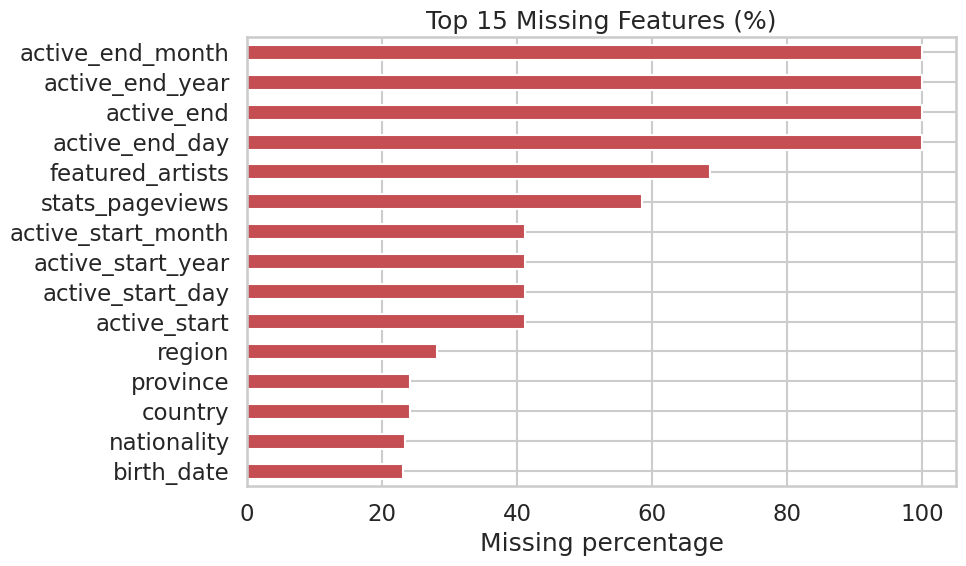

In [8]:
from ml_utils.preprocessing import feature_group_table

feature_lookup = feature_group_table(df).drop_duplicates(subset=['feature']).set_index('feature')
missing_summary = pd.DataFrame(
    {
        'feature': df.columns,
        'missing_count': df.isna().sum().values,
    }
)
missing_summary['missing_pct'] = (100 * missing_summary['missing_count'] / len(df)).round(2)
missing_summary = missing_summary.join(feature_lookup[['group', 'level']], on='feature')
missing_summary['group'] = missing_summary['group'].fillna('derived')
missing_summary['level'] = missing_summary['level'].fillna('song')
missing_summary = missing_summary.sort_values(['missing_pct', 'missing_count'], ascending=False).reset_index(drop=True)

group_missing = (
    missing_summary.groupby(['level', 'group'])[['missing_count', 'missing_pct']]
    .mean()
    .rename(columns={'missing_count': 'avg_missing_count', 'missing_pct': 'avg_missing_pct'})
    .reset_index()
    .sort_values('avg_missing_pct', ascending=False)
)

display(missing_summary)
display(group_missing)

fig, ax = plt.subplots(figsize=(10, 6))
missing_summary.head(15).sort_values('missing_pct').plot.barh(
    x='feature',
    y='missing_pct',
    ax=ax,
    legend=False,
    color='#c44e52',
)
ax.set_title('Top 15 Missing Features (%)')
ax.set_xlabel('Missing percentage')
ax.set_ylabel('')
plt.tight_layout()
plt.show()


## Duplicates And Inconsistent Values

We inspect duplicate identifiers, repeated merged rows, repeated artist-title combinations, and potentially inconsistent categorical labels.


In [9]:
from ml_utils.preprocessing import normalize_text

# ---------- Stage: Data Integrity Flags ----------
# Standardized row-level flags so all checks are aggregated once.
integrity_flags = pd.DataFrame(index=df.index)

integrity_flags["rule_duplicate_song_id"] = df["id_song"].duplicated(keep=False)
integrity_flags["rule_duplicate_full_row"] = df.duplicated(keep=False)
integrity_flags["rule_duplicate_artist_title"] = df.duplicated(
    subset=["name", "full_title"], keep=False
)

name_artist_norm = df["name_artist"].map(normalize_text)
name_norm = df["name"].map(normalize_text)
integrity_flags["rule_artist_name_mismatch"] = name_artist_norm != name_norm

# Optional global flag for downstream filtering/debugging
integrity_flags["rule_any_integrity_issue"] = integrity_flags.any(axis=1)

# ---------- Compact Integrity Report ----------
integrity_report = (
    integrity_flags.sum()
    .rename("count")
    .to_frame()
    .assign(pct=lambda x: (100 * x["count"] / len(df)).round(2))
    .reset_index()
    .rename(columns={"index": "check"})
    .sort_values(["count", "check"], ascending=[False, True])
)

display(integrity_report)

# ---------- Focused Samples For Diagnostics ----------
year_col = "final_release_year" if "final_release_year" in df.columns else "release_year"

duplicate_song_examples = (
    df.loc[integrity_flags["rule_duplicate_song_id"],
           ["id_song", "name", "full_title", "album_name", year_col]]
    .sort_values(["id_song", year_col])
    .head(20)
)

artist_name_mismatch_examples = (
    df.loc[integrity_flags["rule_artist_name_mismatch"],
           ["name", "name_artist", "full_title"]]
    .drop_duplicates()
    .head(20)
)

display(duplicate_song_examples)
display(artist_name_mismatch_examples)


,check,count,pct
4,rule_any_integrity_issue,1011,9.05
3,rule_artist_name_mismatch,872,7.81
0,rule_duplicate_song_id,144,1.29
2,rule_duplicate_artist_title,4,0.04
1,rule_duplicate_full_row,0,0.00


,id_song,name,full_title,album_name,final_release_year
848,TR108862,bassi maestro,Sushi Bar by Bassi Maestro,Sushi - EP,2007
8414,TR108862,noyz narcos,SPINE by Noyz Narcos (Ft. Coez),VIRUS,2022
4771,TR135764,ghemon,Nessuno vale quanto te by Ghemon,ORCHIdee,2014
2992,TR135764,emis killa,Giovani eroi by Emis Killa (Ft. Not Good),"Keta Music, Vol. 3",2021
2013,TR190585,coez,Nei treni la notte by Coez (Ft. Frah Quintale),From The Rooftop 2,2022
8617,TR190585,piotta,Serpico by Piotta (Ft. Tiromancino),'na notte infame,2024
1917,TR192351,club dogo,Tornerò Da Re - Redrum Version by Club Dogo,Vile Denaro 10th Anniversary,2007
5912,TR192351,jake la furia,Musica Commerciale by Jake La Furia,Musica Commerciale,2013
5815,TR205970,jack the smoker,24.7 by Jack The Smoker (Ft. Bassi Maestro & Guè),V.Ita,2009
8819,TR205970,rancore,Sigla Catteland by Rancore & DJ Myke,Musica per bambini,2018


,name,name_artist,full_title
344,anna pepe,ANNA,Bando by ANNA
345,anna pepe,ANNA,TT LE GIRLZ by ANNA (Ft. Niky Savage)
346,anna pepe,ANNA,I LOVE IT by ANNA (Ft. Artie 5ive)
347,anna pepe,ANNA,ABC by ANNA (Ft. thasup & Tony Boy)
348,anna pepe,ANNA,30°C by ANNA
349,anna pepe,ANNA,BBE by ANNA (Ft. Lazza)
350,anna pepe,ANNA,BIKINI by ANNA (Ft. Guè)
351,anna pepe,ANNA,UNA TIPA COME ME by ANNA
352,anna pepe,ANNA,HELLO KITTY by ANNA (Ft. Sillyelly)
353,anna pepe,ANNA,VIENI DALLA BADDIE (interlude) by ANNA


In [10]:
for column in ["language", "album_type", "explicit", "region", "country", "nationality"]:
    print(f"\nValue counts for {column}:")
    display(df[column].value_counts(dropna=False).rename("count").to_frame().head(15))



Value counts for language:


,count
language,
it,9352
en,843
pl,588
<NA>,105
es,63
co,48
pt,45
da,18
cs,14



Value counts for album_type:


,count
album_type,
album,9353
single,1544
compilation,191
<NA>,78



Value counts for explicit:


...

,count
region,
<NA>,3142
Lombardia,2662
Campania,1296
Lazio,1154
Veneto,693
Piemonte,599
Sardegna,526
Puglia,350
Liguria,315



Value counts for country:


,count
country,
Italia,8467
<NA>,2699



Value counts for nationality:


,count
nationality,
Italia,8517
<NA>,2609
Argentina,40


In [11]:
df_work = df.copy()

print("rows:", len(df_work))
print("duplicate full rows:", int(df_work.duplicated(keep=False).sum()))
print("duplicate id_song rows:", int(df_work["id_song"].duplicated(keep=False).sum()))
print("duplicate name+full_title rows:", int(df_work.duplicated(subset=["name", "full_title"], keep=False).sum()))

if "domain_plausibility_metadata" in locals():
    nf = domain_plausibility_metadata["numeric_flags"]
    cf = domain_plausibility_metadata["categorical_flags"]
    sf = domain_plausibility_metadata["consistency_flags"]
    
print("rows with any domain issue:", int((nf | cf | sf).any(axis=1).sum()))

rows: 11166
duplicate full rows: 0
duplicate id_song rows: 144
duplicate name+full_title rows: 4
rows with any domain issue: 1219


## Incorrect Dates And Extreme Values (OOD)

We flag impossible dates, implausible years, and suspicious numeric values using both domain rules and robust IQR-based summaries.


In [12]:
from ml_utils.numeric_stats import summarize_outliers

outlier_summary = summarize_outliers(
    df,
    columns=[
        "popularity",
        "modified_popularity",
        "stats_pageviews",
        "bpm",
        "duration_ms",
        "tokens_per_sent",
        "avg_token_per_clause",
        "lexical_density",
        "year",
    ]
)

suspicious_counts = pd.DataFrame(
    [
        {"check": "year_equals_2100", "count": int((df["year"] == 2100).sum())},
        {"check": "negative_popularity", "count": int((df["popularity"] < 0).sum())},
        {"check": "popularity_above_100", "count": int((df["popularity"] > 100).sum())},
        {"check": "bpm_above_300", "count": int((df["bpm"] > 300).sum())},
        {"check": "duration_above_15_minutes", "count": int((df["duration_ms"] > 900000).sum())},
    ]
)


display(outlier_summary)
display(suspicious_counts)


,feature,valid_count,q1,q3,iqr_lower,iqr_upper,iqr_outliers,iqr_outlier_pct,domain_outliers,domain_outlier_pct,min,max
0,popularity,11088,16.000000,47.000000,-30.500000,93.500000,11,0.10,0,0.0,0.000000,100.00
1,modified_popularity,11166,0.000000,0.000000,0.000000,0.000000,78,0.70,0,0.0,0.000000,1.00
2,stats_pageviews,4642,9642.250000,42011.750000,-38912.000000,90566.000000,418,9.00,0,0.0,5006.000000,1971207.00
3,bpm,11101,91.910000,134.620000,27.845000,198.685000,0,0.00,0,0.0,59.970000,191.41
4,duration_ms,11083,170117.500000,227146.500000,84574.000000,312690.000000,491,4.43,0,0.0,11426.000000,1740000.00
5,tokens_per_sent,11090,7.333333,9.431527,4.186042,12.578818,399,3.60,0,0.0,1.500000,400.00
6,avg_token_per_clause,10951,5.889499,8.103230,2.568903,11.423826,594,5.42,0,0.0,2.714286,197.00
7,lexical_density,11090,0.482353,0.542450,0.392207,0.632597,520,4.69,0,0.0,0.000000,1.00
8,year,9692,2008.000000,2020.000000,1990.000000,2038.000000,1117,11.52,0,0.0,1900.000000,2025.00


,check,count
0,year_equals_2100,0
1,negative_popularity,0
2,popularity_above_100,0
3,bpm_above_300,0
4,duration_above_15_minutes,11


## Feature Engineering

We build a single, consolidated feature engineering step that includes the original project features plus additional clustering-oriented features for Task 3.


In [13]:
from ml_utils.numeric_stats import safe_divide, build_weighted_zscore, audio_signature_score, artist_consistency_score, artist_geographic_diversity
from ml_utils.preprocessing import map_region_to_macroarea

# Original project features
df['swear_total'] = df[['swear_IT', 'swear_EN']].fillna(0).sum(axis=1)
df['swear_density_total'] = safe_divide(df['swear_total'], df['n_tokens'])
df['artist_macroarea'] = df['region'].apply(map_region_to_macroarea)
df['sentence_complexity_index'] = build_weighted_zscore(
    df,
    columns=['tokens_per_sent', 'avg_token_per_clause', 'lexical_density', 'char_per_tok'],
    weights=[1, 1, 1, 1],
    min_non_missing=3,
)

# Additional clustering-oriented features
artist_song_count = df.groupby('id_author').size()
df['artist_song_count'] = df['id_author'].map(artist_song_count)

df['audio_signature_score'] = audio_signature_score(df)

current_year = pd.Timestamp.today().year
df['release_recency_years'] = (current_year - df['final_release_year']).clip(lower=0)

df['engagement_ratio'] = safe_divide(df['popularity'], df['stats_pageviews'] + 1)

df['explicit_numeric'] = df['explicit'].map({True: 1, False: 0}).astype('Float64')

df['explicit_content_intensity'] = build_weighted_zscore(
    df,
    columns=['explicit_numeric', 'swear_density_total'],
    weights=[1, 1],
    min_non_missing=1,
)

df['artist_consistency_score'] = artist_consistency_score(df, artist_col='id_author')
df['lyric_audio_balance'] = safe_divide(df['sentence_complexity_index'], df['audio_signature_score'])
df['artist_geographic_diversity'] = artist_geographic_diversity(
    df,
    artist_col='id_author',
    geo_col='region',
)

engineered_additions = pd.DataFrame(
    [
        {
            'feature': 'swear_density_total',
            'formula': '(swear_IT + swear_EN) / n_tokens',
            'motivation': 'Compare profanity across songs with different lyric lengths.',
        },
        {
            'feature': 'artist_macroarea',
            'formula': 'region -> {North, Center, South, Sicily, Sardinia, Missing}',
            'motivation': 'Stabilize the regional comparison by reducing sparsity.',
        },
        {
            'feature': 'sentence_complexity_index',
            'formula': 'mean z-score of tokens_per_sent, avg_token_per_clause, lexical_density, char_per_tok',
            'motivation': 'Capture a broader notion of textual complexity than a single proxy.',
        },
        {
            'feature': 'artist_song_count',
            'formula': 'count of songs per artist',
            'motivation': 'Identifies prolific vs. one-hit artists for segmentation.',
        },
        {
            'feature': 'audio_signature_score',
            'formula': 'mean z-score of centroid, rolloff, flux, flatness, loudness, pitch, rms, zcr',
            'motivation': 'Aggregates audio tonal profile into a single comparable dimension.',
        },
        {
            'feature': 'release_recency_years',
            'formula': 'current_year - final_release_year (clipped at 0)',
            'motivation': 'Captures freshness vs. catalog depth; temporal signal for clustering.',
        },
        {
            'feature': 'engagement_ratio',
            'formula': 'popularity / (stats_pageviews + 1)',
            'motivation': 'Measures popularity efficiency relative to traffic.',
        },
        {
            'feature': 'explicit_content_intensity',
            'formula': 'mean z-score of explicit_numeric and swear_density_total',
            'motivation': 'Combines explicit rating and lyric profanity into one signal.',
        },
        {
            'feature': 'artist_consistency_score',
            'formula': 'mean variance of popularity, duration_ms, swear_density_total across artist songs',
            'motivation': 'Lower values indicate more consistent artist behavior.',
        },
        {
            'feature': 'lyric_audio_balance',
            'formula': 'sentence_complexity_index / audio_signature_score',
            'motivation': 'Contrasts lyrical density with the overall audio profile.',
        },
        {
            'feature': 'artist_geographic_diversity',
            'formula': 'count of distinct regions observed per artist',
            'motivation': 'Highlights artists with broader geographic footprints in the data.',
        },
    ]
)

display(engineered_additions)

feature_snapshot = [
    'swear_density_total',
    'artist_macroarea',
    'sentence_complexity_index',
    'artist_song_count',
    'audio_signature_score',
    'release_recency_years',
    'engagement_ratio',
    'explicit_content_intensity',
    'artist_consistency_score',
    'lyric_audio_balance',
    'artist_geographic_diversity',
]

display(df[feature_snapshot].head())
display(df['artist_macroarea'].value_counts(dropna=False).rename('song_count').to_frame())
display(df[feature_snapshot].isna().sum().rename('missing_count').to_frame())


,feature,formula,motivation
0,swear_density_total,(swear_IT + swear_EN) / n_tokens,Compare profanity across songs with different ...
1,artist_macroarea,"region -> {North, Center, South, Sicily, Sardi...",Stabilize the regional comparison by reducing ...
2,sentence_complexity_index,"mean z-score of tokens_per_sent, avg_token_per...",Capture a broader notion of textual complexity...
3,artist_song_count,count of songs per artist,Identifies prolific vs. one-hit artists for se...
4,audio_signature_score,"mean z-score of centroid, rolloff, flux, flatn...",Aggregates audio tonal profile into a single c...
5,release_recency_years,current_year - final_release_year (clipped at 0),Captures freshness vs. catalog depth; temporal...
6,engagement_ratio,popularity / (stats_pageviews + 1),Measures popularity efficiency relative to tra...
7,explicit_content_intensity,mean z-score of explicit_numeric and swear_den...,Combines explicit rating and lyric profanity i...
8,artist_consistency_score,"mean variance of popularity, duration_ms, swea...",Lower values indicate more consistent artist b...
9,lyric_audio_balance,sentence_complexity_index / audio_signature_score,Contrasts lyrical density with the overall aud...


,swear_density_total,artist_macroarea,sentence_complexity_index,artist_song_count,audio_signature_score,release_recency_years,engagement_ratio,explicit_content_intensity,artist_consistency_score,lyric_audio_balance,artist_geographic_diversity
0,0.005938,Missing,0.506235,77,-0.380904,33,0.005832,-0.511936,2.410162e+09,-1.329034,NaN
1,0.018382,Missing,0.203713,77,0.105958,33,0.007124,0.166186,2.410162e+09,1.922588,NaN
2,0.012926,Missing,-0.199482,77,-0.31816,33,<NA>,-0.131151,2.410162e+09,0.626988,NaN
3,0.0,Missing,-0.672487,77,-0.934733,28,<NA>,-0.835531,2.410162e+09,0.719442,NaN
4,0.012278,Missing,-0.079249,77,0.70493,12,<NA>,-0.166444,2.410162e+09,-0.112421,NaN


,song_count
artist_macroarea,
North,4368
Missing,3142
South,1715
Center,1233
Sardinia,526
Sicily,182


,missing_count
swear_density_total,76
artist_macroarea,0
sentence_complexity_index,76
artist_song_count,0
audio_signature_score,64
release_recency_years,66
engagement_ratio,6526
explicit_content_intensity,73
artist_consistency_score,73
lyric_audio_balance,140


## Distribution Analysis

We inspect the main project variables with histograms, boxplots, and violin plots. For heavily skewed variables we also inspect a `log1p` transformed view.


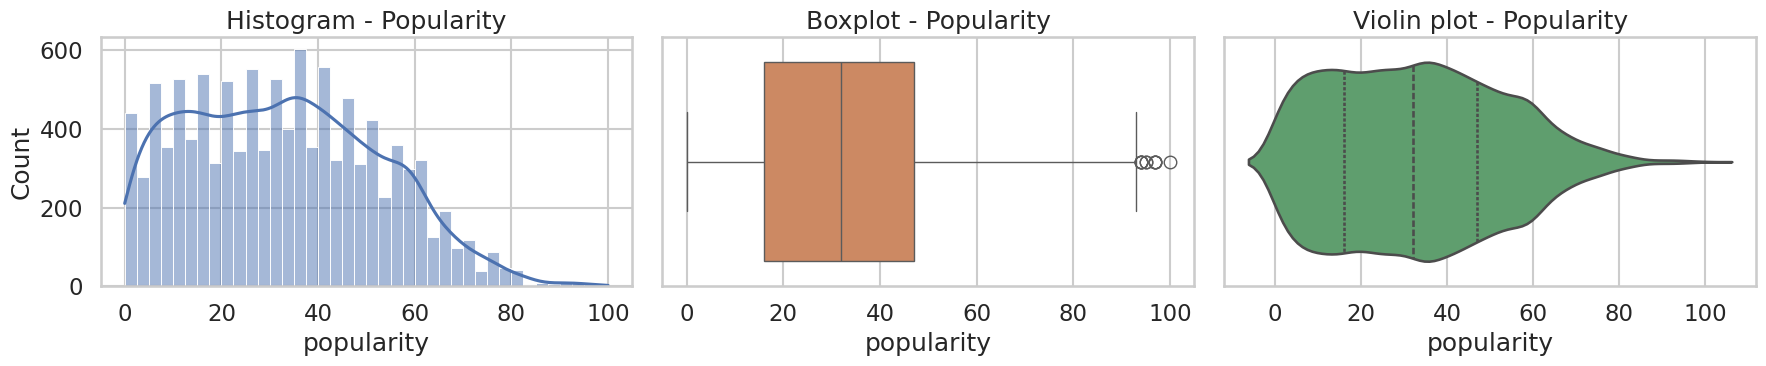

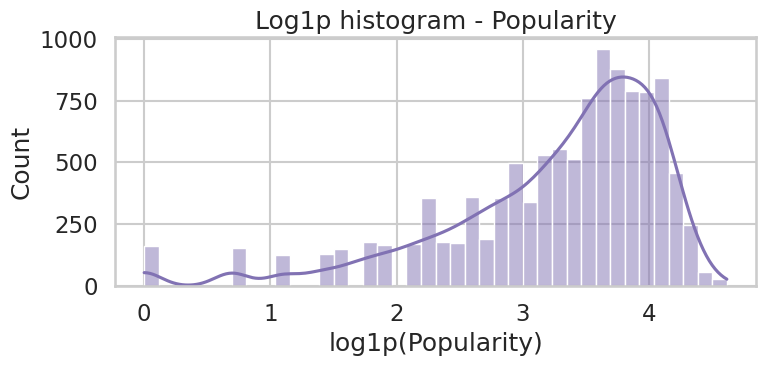

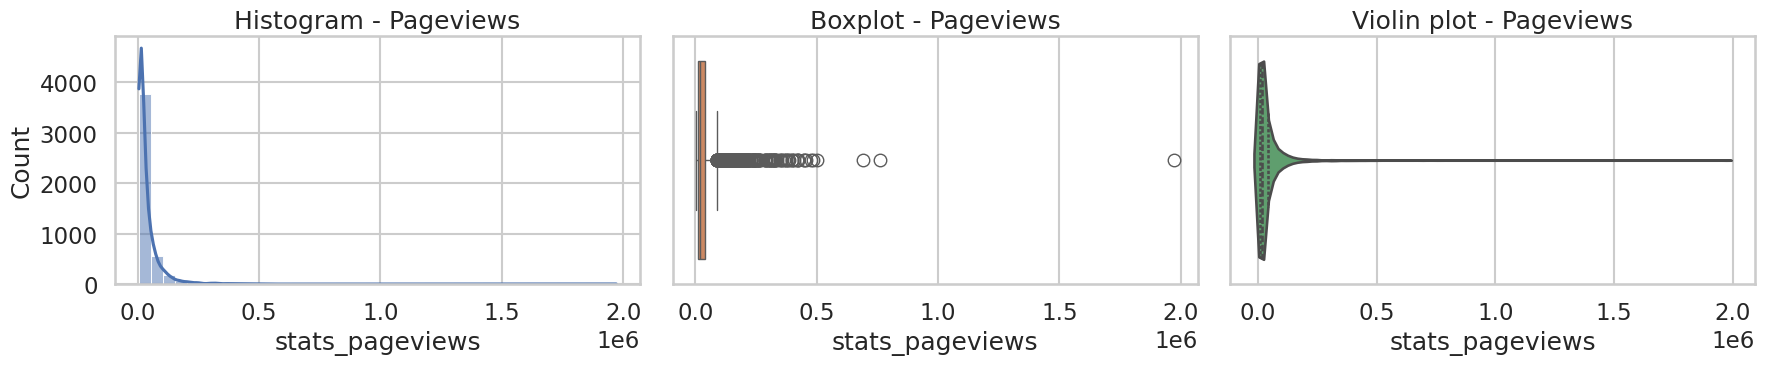

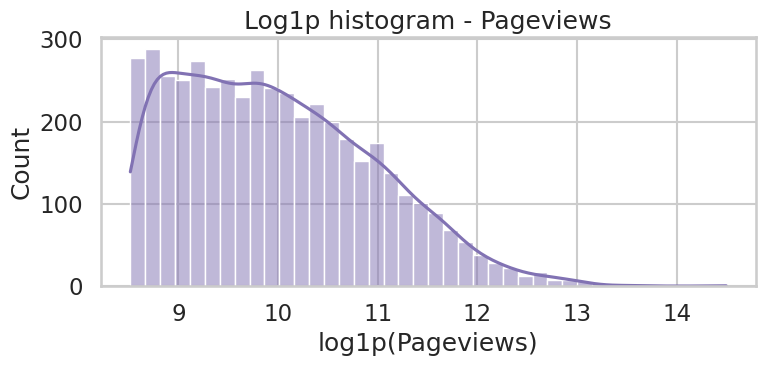

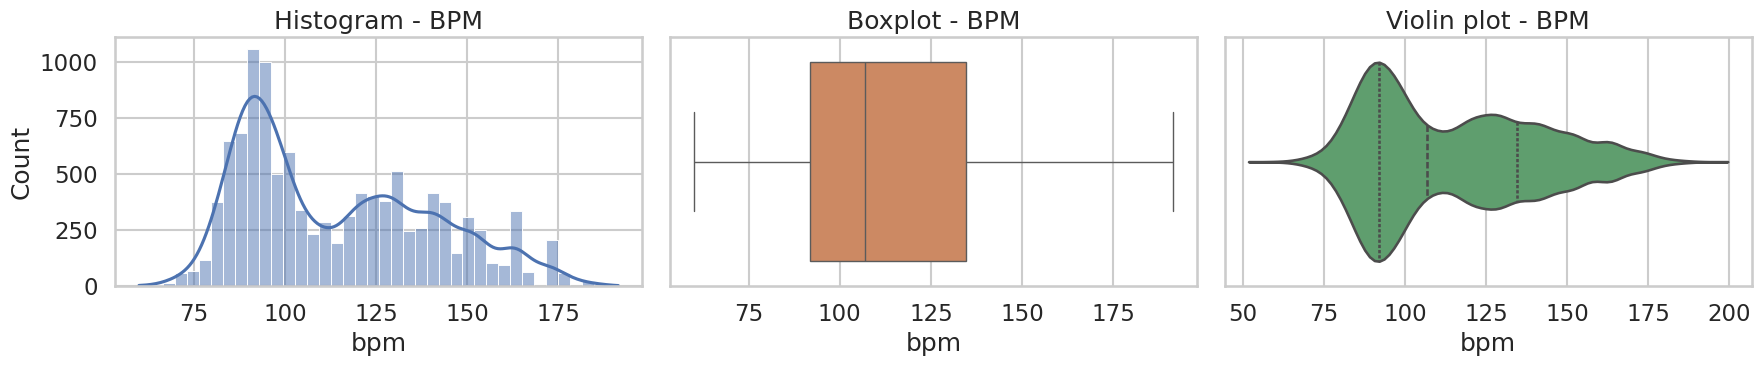

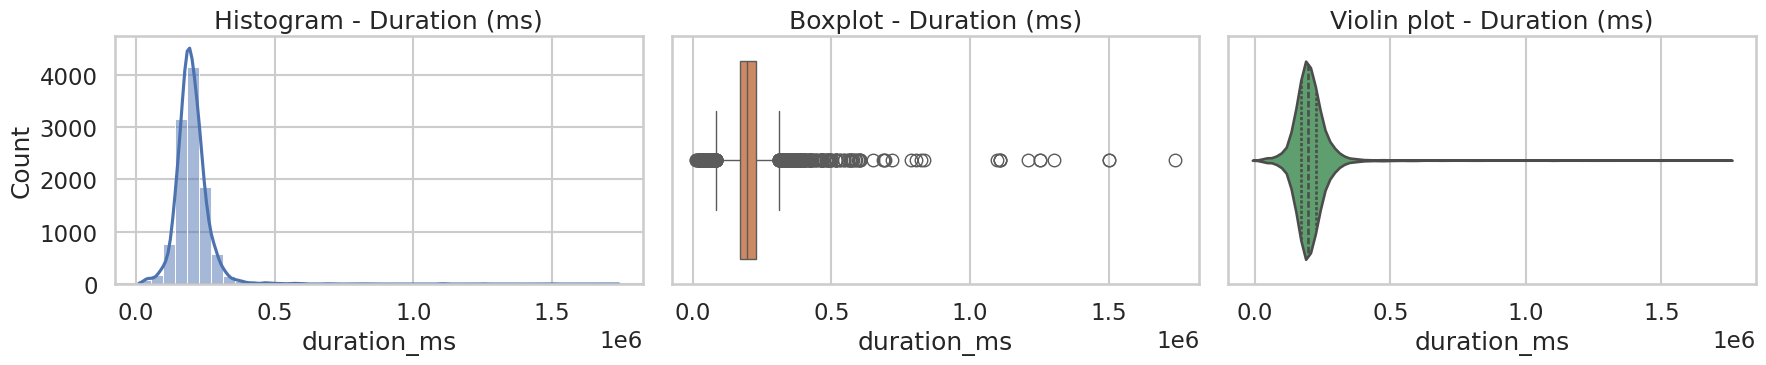

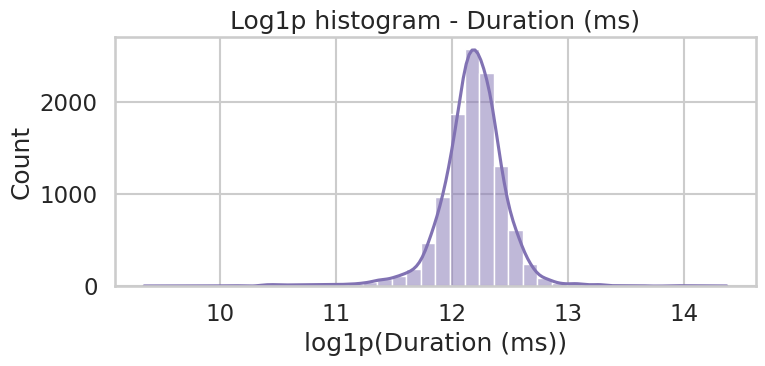

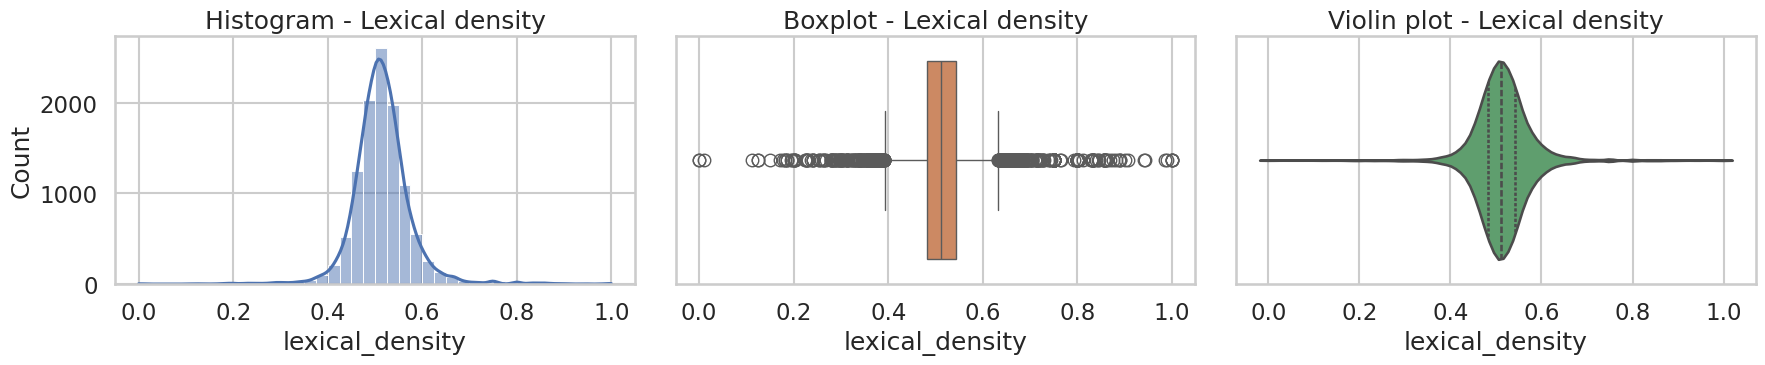

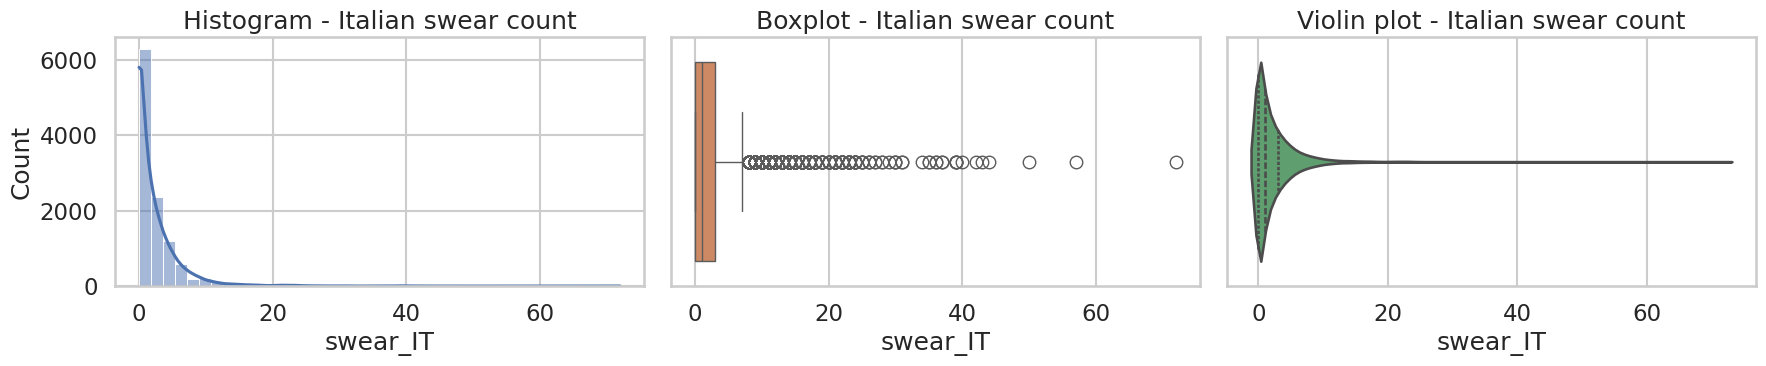

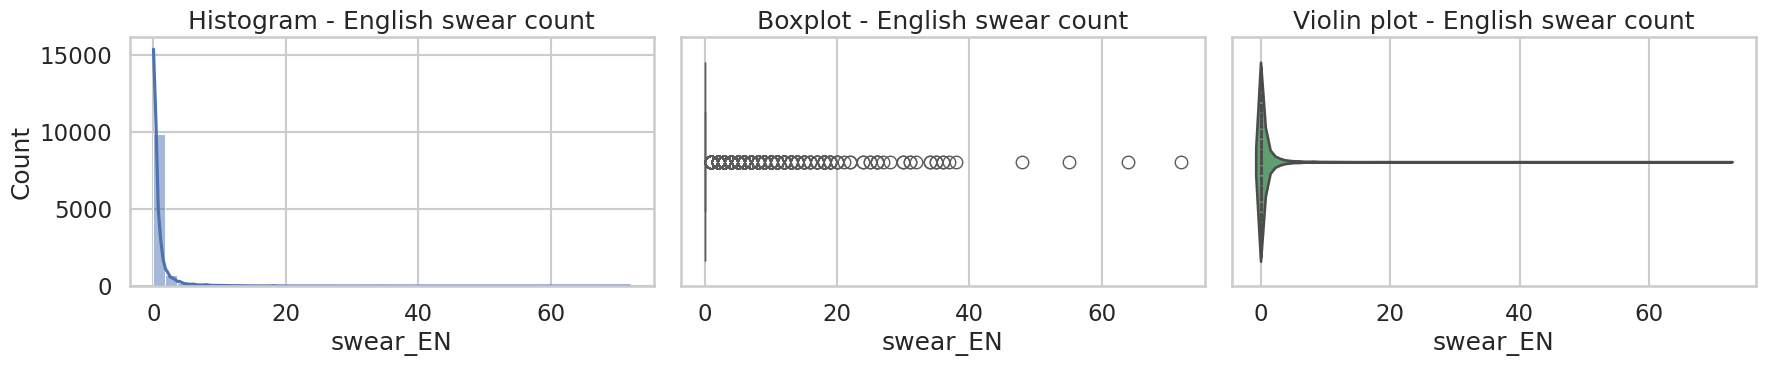

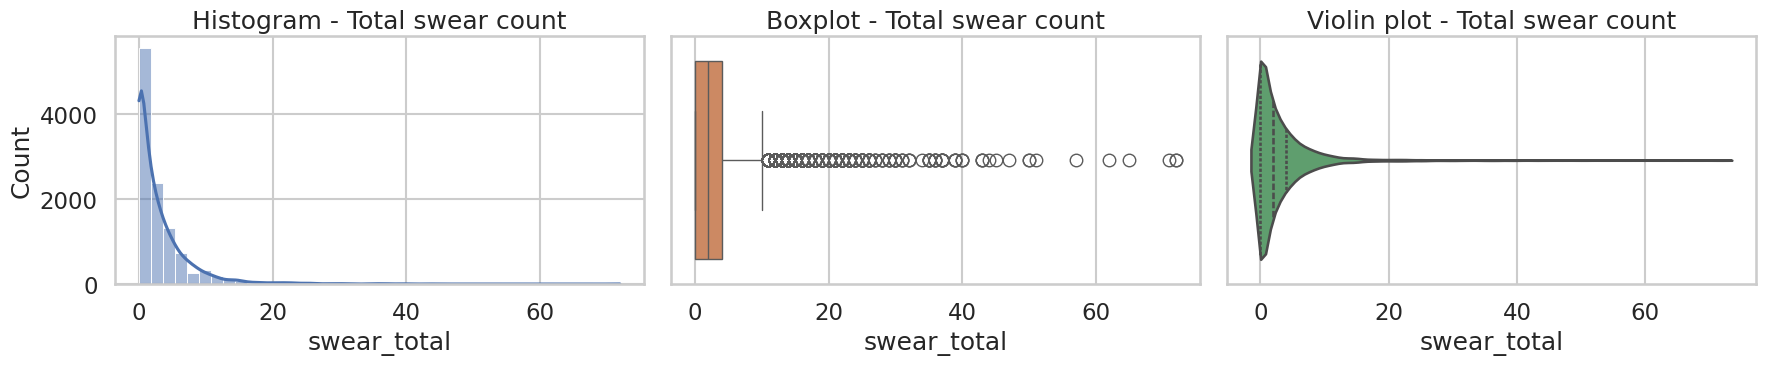

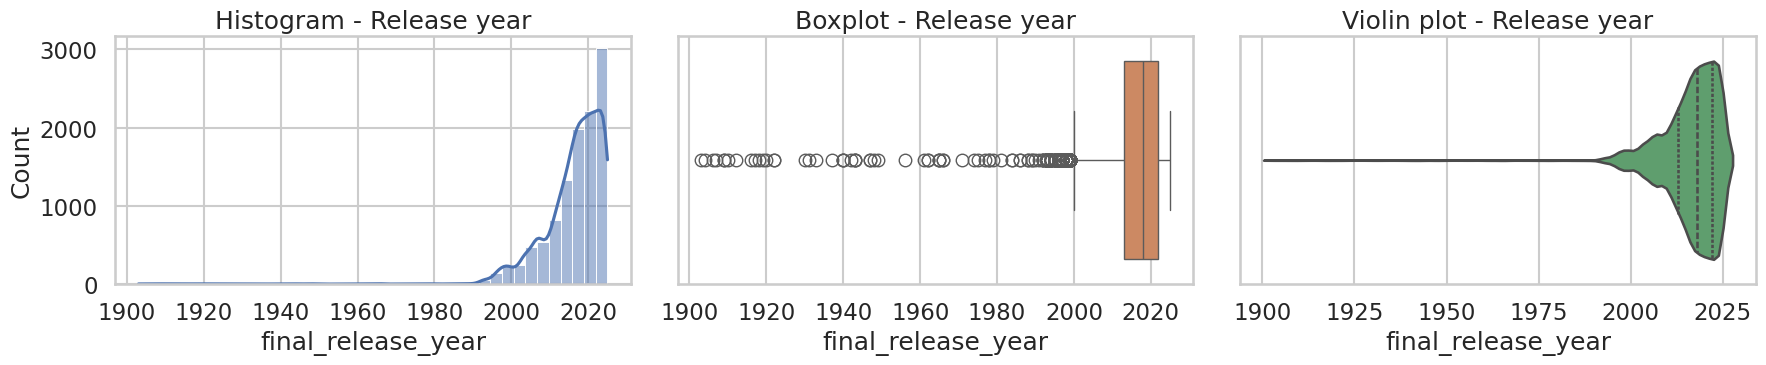

In [14]:
def plot_distribution_triplet(data, column, pretty_name=None, log1p=False):
    series = data[column].dropna()
    if series.empty:
        print(f"Skipping {column}: no valid values.")
        return

    label = pretty_name or column
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    sns.histplot(series, bins=40, kde=True, ax=axes[0], color="#4c72b0")
    axes[0].set_title(f"Histogram - {label}")

    sns.boxplot(x=series, ax=axes[1], color="#dd8452")
    axes[1].set_title(f"Boxplot - {label}")

    sns.violinplot(x=series, ax=axes[2], color="#55a868", inner="quartile")
    axes[2].set_title(f"Violin plot - {label}")

    plt.tight_layout()
    plt.show()

    if log1p:
        non_negative = series[series >= 0]
        if not non_negative.empty:
            fig, ax = plt.subplots(figsize=(8, 4))
            sns.histplot(np.log1p(non_negative), bins=40, kde=True, ax=ax, color="#8172b3")
            ax.set_title(f"Log1p histogram - {label}")
            ax.set_xlabel(f"log1p({label})")
            plt.tight_layout()
            plt.show()

variables_to_plot = [
    ("popularity", "Popularity", True),
    ("stats_pageviews", "Pageviews", True),
    ("bpm", "BPM", False),
    ("duration_ms", "Duration (ms)", True),
    ("lexical_density", "Lexical density", False),
    ("swear_IT", "Italian swear count", False),
    ("swear_EN", "English swear count", False),
    ("swear_total", "Total swear count", False),
    ("final_release_year", "Release year", False),
]

for column, label, use_log in variables_to_plot:
    plot_distribution_triplet(df, column, pretty_name=label, log1p=use_log)

## Swear Density And Regionality

This section connects the custom feature engineering to the project question by comparing profanity density across artist macro-areas and analysing how the geographic origin deviates from the most common origin (north).


,count,mean,median,std
artist_macroarea,,,,
North,4293,0.006735,0.003831,0.009696
Center,1233,0.006654,0.00431,0.008918
South,1715,0.004206,0.001848,0.007042
Sicily,182,0.004603,0.00274,0.00684
Sardinia,525,0.007032,0.005085,0.007495
Missing,3142,0.005681,0.002821,0.009767


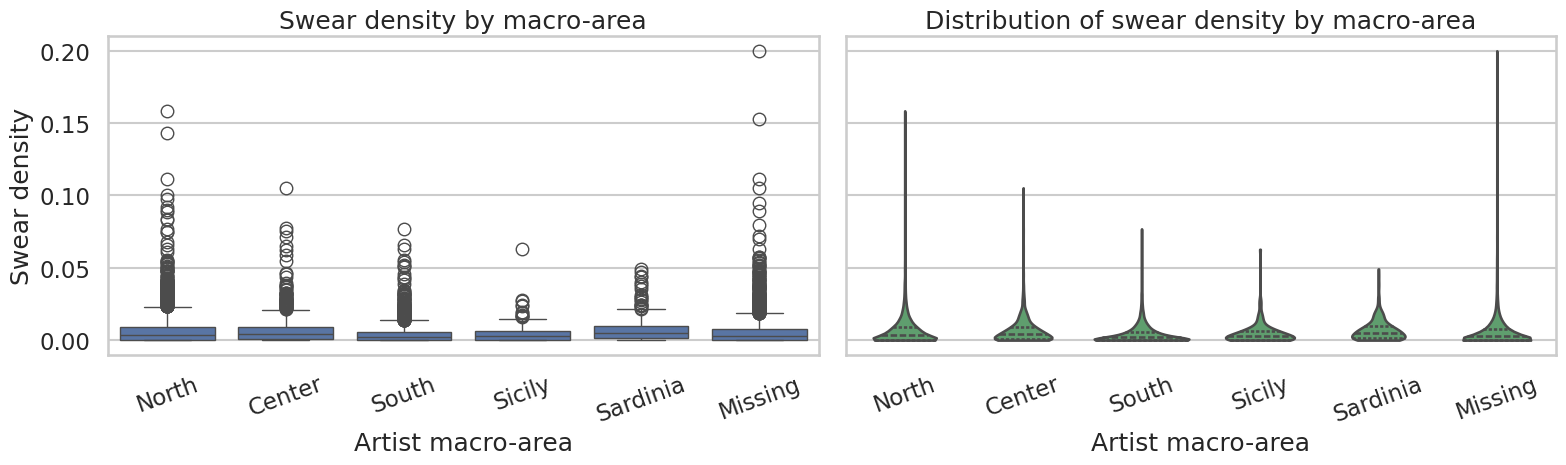

,song_count
artist_macroarea,
North,4368
Center,1233
South,1715
Sicily,182
Sardinia,526
Missing,3142


,count,mean,median,max
artist_macroarea,,,,
North,40,0.314583,0.000000,0.958333
Center,10,0.725000,0.666667,0.958333
South,13,0.663462,0.583333,0.958333
Sicily,1,0.958333,0.958333,0.958333
Sardinia,4,0.833333,0.833333,0.833333
Missing,0,NaN,NaN,NaN


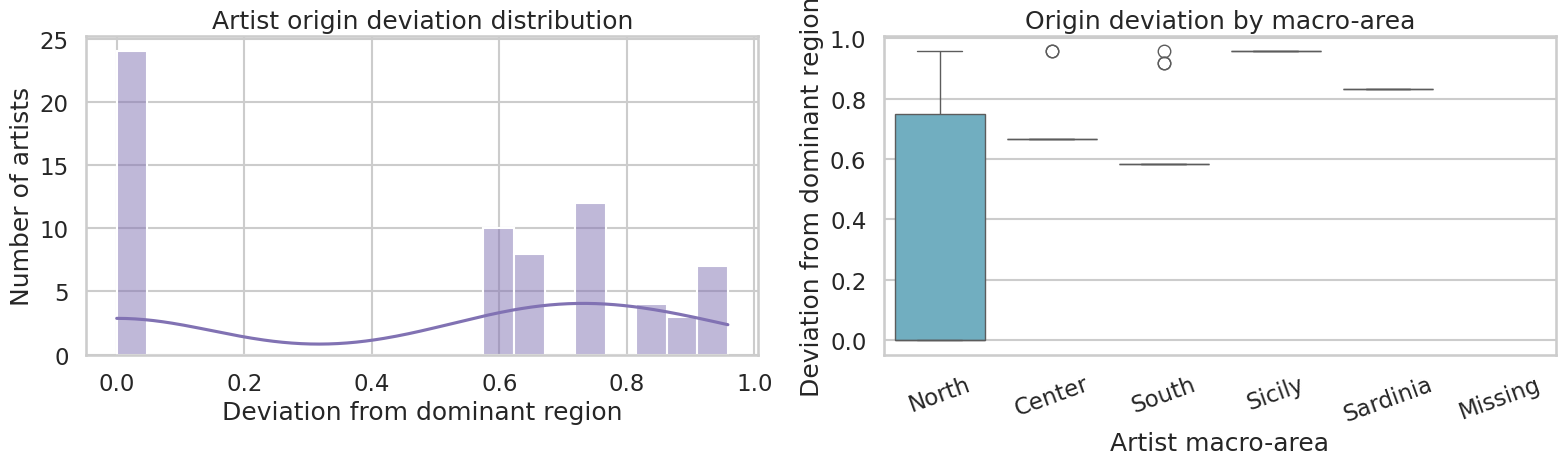

Interpretation note: higher values indicate artists coming from less represented origins, while 0 indicates the dominant origin group.


In [15]:
macroarea_order = ["North", "Center", "South", "Sicily", "Sardinia", "Missing"]
macroarea_stats = (
    df.groupby("artist_macroarea")["swear_density_total"]
    .agg(["count", "mean", "median", "std"])
    .reindex(macroarea_order)
)

display(macroarea_stats)

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)
sns.boxplot(
    data=df,
    x="artist_macroarea",
    y="swear_density_total",
    order=macroarea_order,
    ax=axes[0],
    color="#4c72b0",
)
axes[0].set_title("Swear density by macro-area")
axes[0].set_xlabel("Artist macro-area")
axes[0].set_ylabel("Swear density")
axes[0].tick_params(axis="x", rotation=20)

sns.violinplot(
    data=df,
    x="artist_macroarea",
    y="swear_density_total",
    order=macroarea_order,
    ax=axes[1],
    color="#55a868",
    inner="quartile",
    cut=0,
)
axes[1].set_title("Distribution of swear density by macro-area")
axes[1].set_xlabel("Artist macro-area")
axes[1].set_ylabel("Swear density")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

coverage_by_macroarea = df["artist_macroarea"].value_counts().reindex(macroarea_order)
display(coverage_by_macroarea.rename("song_count").to_frame())

# Geographic deviation representation (artist-level)
artist_geo = (
    df[["id_author", "artist_macroarea", "artist_geographic_diversity"]]
    .drop_duplicates(subset=["id_author"])
)

geo_deviation_summary = (
    artist_geo.groupby("artist_macroarea")["artist_geographic_diversity"]
    .agg(["count", "mean", "median", "max"])
    .reindex(macroarea_order)
)
display(geo_deviation_summary)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.histplot(
    artist_geo["artist_geographic_diversity"],
    bins=20,
    kde=True,
    ax=axes[0],
    color="#8172b3",
)
axes[0].set_title("Artist origin deviation distribution")
axes[0].set_xlabel("Deviation from dominant region")
axes[0].set_ylabel("Number of artists")

sns.boxplot(
    data=artist_geo,
    x="artist_macroarea",
    y="artist_geographic_diversity",
    order=macroarea_order,
    ax=axes[1],
    color="#64b5cd",
)
axes[1].set_title("Origin deviation by macro-area")
axes[1].set_xlabel("Artist macro-area")
axes[1].set_ylabel("Deviation from dominant region")
axes[1].tick_params(axis="x", rotation=20)
    



plt.tight_layout()
plt.show()

print(
    "Interpretation note: higher values indicate artists coming from less represented origins, "
    "while 0 indicates the dominant origin group."
)


,metric,count,percentage
0,rows_with_mood_label,11087,99.29
1,rows_with_missing_mood_label,79,0.71


,audio_feature,missing_count
7,pitch,79
0,bpm,65
5,centroid,64
8,flatness,64
3,flux,64
1,loudness,64
2,rms,64
6,rolloff,64
4,spectral_complexity,64
9,zcr,64


Mood labeling thresholds: a33=0.461, a66=0.559, a80=0.610, v33=0.336, v66=0.412


,song_count
mood_label,
energetic,928
cheerful,2328
calm,1044
sad,1518
tense,1354
aggressive,976
neutral,2939


,song_count,mean_swear_total,mean_swear_density,median_geo_deviation,mean_geo_deviation
mood_label,,,,,
energetic,928,4.483836,0.008224,0.666667,0.531936
cheerful,2328,3.618127,0.00703,0.666667,0.480523
calm,1044,2.979885,0.005788,0.583333,0.480440
sad,1518,2.046772,0.004451,0.583333,0.477108
tense,1354,3.325702,0.006245,0.666667,0.501949
aggressive,976,2.254098,0.004593,0.583333,0.466035
neutral,2939,2.873426,0.005823,0.666667,0.503260


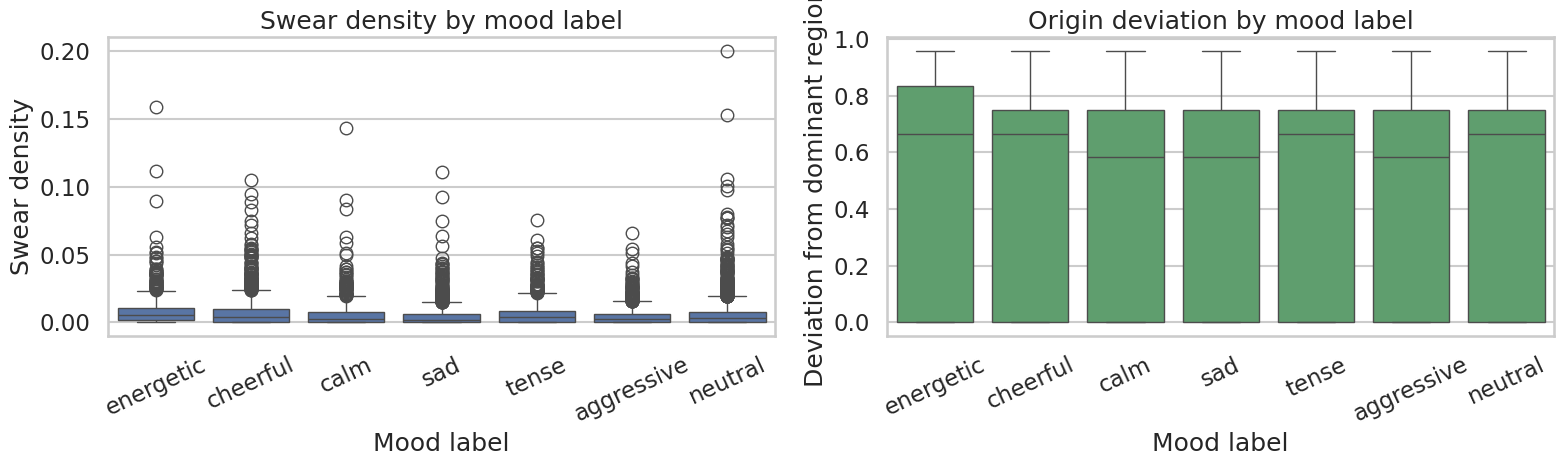

Interpretation note: Mood labels are based on a weighted combination of normalized audio features, following academic MER practice. Rows with incomplete audio inputs keep a missing mood label and are excluded from mood-specific summaries and plots.


In [16]:
# Valence–Arousal Mood Labeling (MER-inspired)
# Academic mapping of audio features to 2D mood space with quantile-based thresholds

from ml_utils.numeric_stats import compute_mer_mood_features

mood_feature_frame, mood_metadata = compute_mer_mood_features(df)
df[mood_feature_frame.columns] = mood_feature_frame

mood_coverage = pd.DataFrame(
    [
        {
            "metric": "rows_with_mood_label",
            "count": mood_metadata["n_complete_rows"],
            "percentage": round(100 * mood_metadata["n_complete_rows"] / len(df), 2),
        },
        {
            "metric": "rows_with_missing_mood_label",
            "count": mood_metadata["n_missing_rows"],
            "percentage": round(100 * mood_metadata["n_missing_rows"] / len(df), 2),
        },
    ]
)
display(mood_coverage)

mood_missing_inputs = (
    pd.Series(mood_metadata["missing_counts_by_feature"], name="missing_count")
    .rename_axis("audio_feature")
    .reset_index()
    .sort_values(["missing_count", "audio_feature"], ascending=[False, True])
)
display(mood_missing_inputs)

print(
    f"Mood labeling thresholds: a33={mood_metadata['thresholds']['a33']:.3f}, "
    f"a66={mood_metadata['thresholds']['a66']:.3f}, a80={mood_metadata['thresholds']['a80']:.3f}, "
    f"v33={mood_metadata['thresholds']['v33']:.3f}, v66={mood_metadata['thresholds']['v66']:.3f}"
)

# Summary table: mood label counts and mean audio features
mood_order = ["energetic", "cheerful", "calm", "sad", "tense", "aggressive", "neutral"]
mood_counts = df["mood_label"].value_counts().reindex(mood_order).fillna(0).astype(int)
display(mood_counts.rename("song_count").to_frame())

mood_profile = (
    df.groupby("mood_label")
    .agg(
        song_count=("mood_label", "size"),
        mean_swear_total=("swear_total", "mean"),
        mean_swear_density=("swear_density_total", "mean"),
        median_geo_deviation=("artist_geographic_diversity", "median"),
        mean_geo_deviation=("artist_geographic_diversity", "mean"),
    )
    .reindex(mood_order)
)
display(mood_profile)

# Visualization: boxplots for swear density and geo deviation by mood
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.boxplot(
    data=df,
    x="mood_label",
    y="swear_density_total",
    order=mood_order,
    ax=axes[0],
    color="#4c72b0",
)
axes[0].set_title("Swear density by mood label")
axes[0].set_xlabel("Mood label")
axes[0].set_ylabel("Swear density")
axes[0].tick_params(axis="x", rotation=25)

sns.boxplot(
    data=df,
    x="mood_label",
    y="artist_geographic_diversity",
    order=mood_order,
    ax=axes[1],
    color="#55a868",
)
axes[1].set_title("Origin deviation by mood label")
axes[1].set_xlabel("Mood label")
axes[1].set_ylabel("Deviation from dominant region")
axes[1].tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()

print(
    "Interpretation note: Mood labels are based on a weighted combination of normalized audio features, following academic MER practice. Rows with incomplete audio inputs keep a missing mood label and are excluded from mood-specific summaries and plots."
)


## Correlation And Redundancy Analysis

We restrict the correlation matrices to cleaned numeric variables, compare Pearson and Spearman correlation, and highlight strongly related pairs.


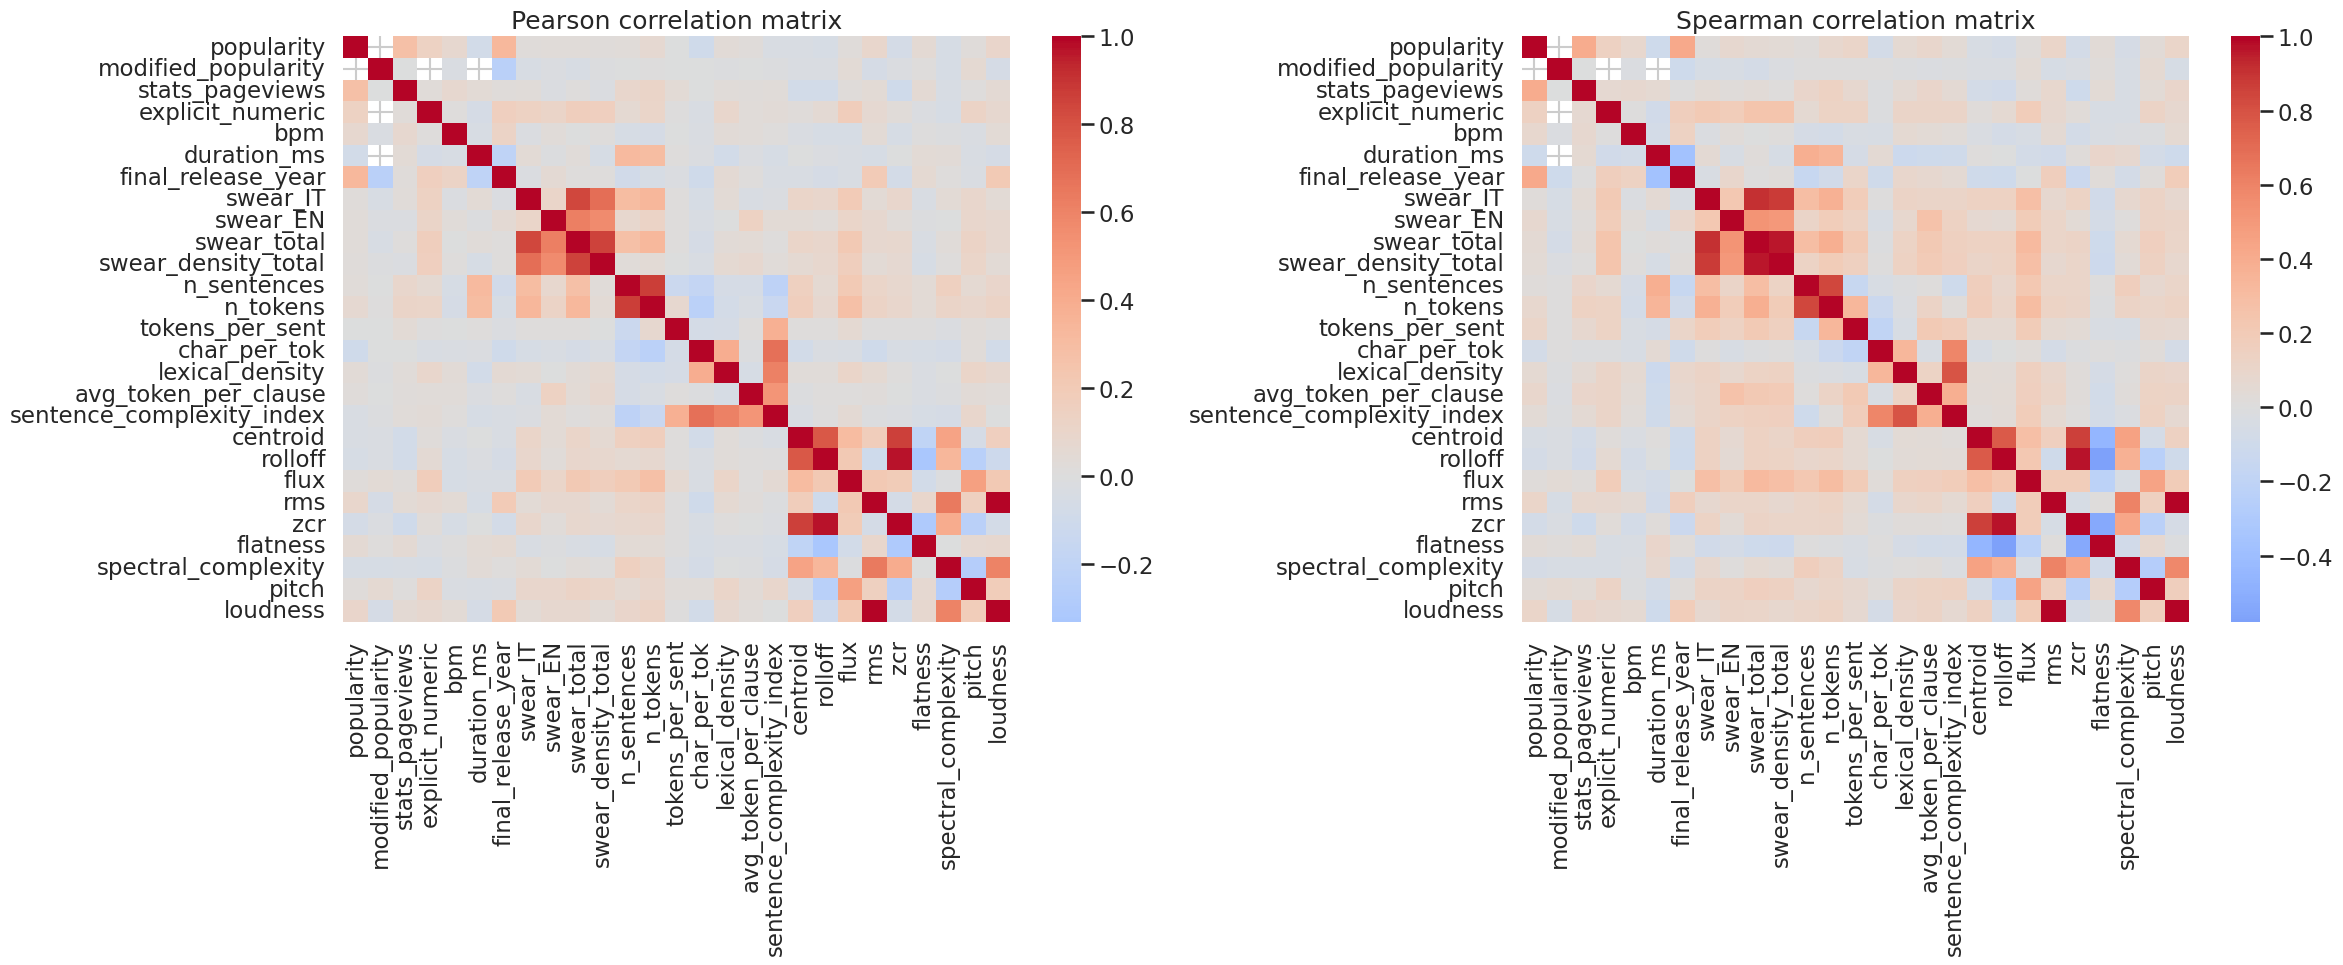

,feature_a,feature_b,correlation
593,rms,loudness,0.995555
535,rolloff,zcr,0.969101
309,n_sentences,n_tokens,0.867722
508,centroid,zcr,0.864465
253,swear_total,swear_density_total,0.850815
198,swear_IT,swear_total,0.842240
505,centroid,rolloff,0.775666


,popularity,stats_pageviews,explicit_numeric,swear_density_total,sentence_complexity_index,bpm,duration_ms,final_release_year
avg_token_per_clause,0.021401,0.018579,0.027799,0.077930,0.521173,0.031220,-0.016125,0.013578
bpm,0.069836,0.073400,0.009082,0.010694,0.012966,1.000000,-0.040986,0.118684
centroid,-0.037100,-0.076413,0.022023,0.064252,-0.030860,-0.024498,-0.002794,-0.038276
char_per_tok,-0.098389,-0.004183,-0.031418,-0.038724,0.687776,-0.028943,-0.020632,-0.101639
duration_ms,-0.079879,0.043708,-0.057105,-0.048171,-0.051392,-0.040986,1.000000,-0.202300
explicit_numeric,0.140699,0.028444,1.000000,0.162586,0.035246,0.009082,-0.057105,0.162872
final_release_year,0.333331,0.022875,0.162872,0.013925,-0.034284,0.118684,-0.202300,1.000000
flatness,0.049920,0.051428,-0.021993,-0.054065,-0.047823,0.006226,0.044633,0.057348
flux,0.018733,0.019972,0.175525,0.166526,0.051673,-0.054072,-0.035193,-0.032673
lexical_density,0.035050,0.027684,0.090914,0.062765,0.614668,0.035023,-0.079131,0.050584


In [17]:
correlation_columns = [
    'popularity',
    'modified_popularity',
    'stats_pageviews',
    'explicit_numeric',
    'bpm',
    'duration_ms',
    'final_release_year',
    'swear_IT',
    'swear_EN',
    'swear_total',
    'swear_density_total',
    'n_sentences',
    'n_tokens',
    'tokens_per_sent',
    'char_per_tok',
    'lexical_density',
    'avg_token_per_clause',
    'sentence_complexity_index',
    'centroid',
    'rolloff',
    'flux',
    'rms',
    'zcr',
    'flatness',
    'spectral_complexity',
    'pitch',
    'loudness',
]

corr_df = df[correlation_columns].copy()
pearson_corr = corr_df.corr(method='pearson')
spearman_corr = corr_df.corr(method='spearman')

fig, axes = plt.subplots(1, 2, figsize=(24, 10))
sns.heatmap(pearson_corr, cmap='coolwarm', center=0, ax=axes[0])
axes[0].set_title('Pearson correlation matrix')

sns.heatmap(spearman_corr, cmap='coolwarm', center=0, ax=axes[1])
axes[1].set_title('Spearman correlation matrix')

plt.tight_layout()
plt.show()

def top_correlation_pairs(corr_matrix, threshold=0.7):
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    pairs = (
        upper.stack()
        .rename('correlation')
        .reset_index()
        .rename(columns={'level_0': 'feature_a', 'level_1': 'feature_b'})
    )
    return pairs.loc[pairs['correlation'].abs() >= threshold].sort_values(
        'correlation',
        key=lambda s: s.abs(),
        ascending=False,
    )

high_corr_pairs = top_correlation_pairs(pearson_corr, threshold=0.7)
focus_features = [
    'popularity',
    'stats_pageviews',
    'explicit_numeric',
    'swear_density_total',
    'sentence_complexity_index',
    'bpm',
    'duration_ms',
    'final_release_year',
]

focus_corr = pearson_corr.loc[focus_features, corr_df.columns].T.sort_index()

display(high_corr_pairs)
display(focus_corr)


After Correlation Analysis, we identify redundant features and select a subset of non-redundant features for later modeling.

In [18]:
from ml_utils.constants import FEATURE_GROUPS 
from ml_utils.correlation_selection import build_correlation_groups, compute_feature_keep_scores, select_redundant_features

# Correlation-aware feature subset selection (points 1-4 of the strategy)

# 1) Build redundancy groups from Pearson correlation

# 2) Score features with a documented keep-score function

# 3) Keep one anchor per group

# 4) Keep a second feature only when it adds distinct signal



candidate_features = [c for c in correlation_columns if c in df.columns]

target_col = "target_macroarea_code" if "target_macroarea_code" in df.columns else None



# Build semantic groups from known feature families

semantic_group_map = {}

for group_name, cols in FEATURE_GROUPS.items():

    for col in cols:

        semantic_group_map[col] = group_name



# Add engineered features if documented in engineered_docs

if "engineered_docs" in locals() and {"feature", "family"}.issubset(engineered_docs.columns):

    for _, row in engineered_docs[["feature", "family"]].dropna().iterrows():

        semantic_group_map[str(row["feature"])] = str(row["family"])



corr_matrix, redundancy_groups = build_correlation_groups(

    df=df,

    feature_columns=candidate_features,

    method="pearson",

    corr_threshold=0.85,

    min_periods=30,

)



feature_scores = compute_feature_keep_scores(

    df=df,

    feature_columns=candidate_features,

    target_column=target_col,

    semantic_group_map=semantic_group_map,

)



selected_score_table, selection_decisions, selected_features_for_modeling = select_redundant_features(

    corr_matrix=corr_matrix,

    redundancy_groups=redundancy_groups,

    score_table=feature_scores,

    semantic_group_map=semantic_group_map,

    target_corr_delta=0.05,

    hard_drop_threshold=0.95,

    max_keep_per_group=2,

)



# ---------- Human-readable reporting ----------

score_cols = [

    "feature",

    "semantic_group",

    "keep_score",

    "target_relevance",

    "low_missingness",

    "stability",

]

decision_view = selection_decisions.merge(feature_scores[score_cols], on="feature", how="left")



decision_order = {"keep_anchor": 0, "keep_secondary": 1, "drop": 2}

decision_view["decision_order"] = decision_view["decision"].map(decision_order).fillna(9)

decision_view = decision_view.sort_values(["group_id", "decision_order", "keep_score"], ascending=[True, True, False])



for col in ["keep_score", "target_relevance", "low_missingness", "stability"]:

    decision_view[col] = decision_view[col].round(3)



summary_table = pd.DataFrame(

    {

        "metric": [

            "candidate_features",

            "correlation_groups",

            "anchors_kept",

            "secondary_kept",

            "features_dropped_in_groups",

            "selected_features_from_groups",

        ],

        "value": [

            len(candidate_features),

            len(redundancy_groups),

            int((decision_view["decision"] == "keep_anchor").sum()),

            int((decision_view["decision"] == "keep_secondary").sum()),

            int((decision_view["decision"] == "drop").sum()),

            len(selected_features_for_modeling),

        ],

    }

)

def _max_abs_corr_in_group(group_features):

    if len(group_features) < 2:

        return np.nan

    sub = corr_matrix.loc[group_features, group_features].abs()
    
    upper = sub.where(np.triu(np.ones(sub.shape), k=1).astype(bool))

    values = upper.stack()

    return np.nan if values.empty else float(values.max())



group_rows = []

for idx, group_features in enumerate(redundancy_groups, start=1):

    group_dec = decision_view[decision_view["group_id"] == idx]

    anchor = group_dec.loc[group_dec["decision"] == "keep_anchor", "feature"]

    secondaries = group_dec.loc[group_dec["decision"] == "keep_secondary", "feature"].tolist()

    dropped = group_dec.loc[group_dec["decision"] == "drop", "feature"].tolist()

    group_rows.append(

        {

            "group_id": idx,

            "group_size": len(group_features),

            "max_abs_corr": round(_max_abs_corr_in_group(group_features), 3),

            "anchor": anchor.iloc[0] if not anchor.empty else "",

            "kept_secondary": ", ".join(secondaries) if secondaries else "-",

            "dropped": ", ".join(dropped) if dropped else "-",

        }

    )



group_overview = pd.DataFrame(group_rows)



selected_details = (

    decision_view[decision_view["decision"].isin(["keep_anchor", "keep_secondary"])]

    .sort_values(["keep_score", "decision_order"], ascending=[False, True])

    [["group_id", "feature", "decision", "semantic_group", "keep_score", "reason"]]

    .rename(columns={"decision": "selection_role", "reason": "why_kept"})

    .reset_index(drop=True)

)



dropped_details = (

    decision_view[decision_view["decision"] == "drop"]

    .sort_values(["group_id", "keep_score"], ascending=[True, False])

    [["group_id", "feature", "semantic_group", "keep_score", "reason"]]

    .rename(columns={"reason": "why_dropped"})

    .reset_index(drop=True)

)



print("Feature-selection summary (correlation-aware, points 1-4)")

display(summary_table)



print("Group-level decisions")

display(group_overview)



print("Kept features (for next analysis step)")

display(selected_details)



if not dropped_details.empty:

    print("Dropped features inside correlated groups")

    display(dropped_details)



if target_col is None:

    print("Note: target_relevance is 0 because no numeric target column is currently available.")


Feature-selection summary (correlation-aware, points 1-4)


,metric,value
0,candidate_features,27
1,correlation_groups,4
2,anchors_kept,4
3,secondary_kept,3
4,features_dropped_in_groups,2
5,selected_features_from_groups,7


Group-level decisions


,group_id,group_size,max_abs_corr,anchor,kept_secondary,dropped
0,1,3,0.969,centroid,zcr,rolloff
1,2,2,0.996,rms,-,loudness
2,3,2,0.868,n_sentences,n_tokens,-
3,4,2,0.851,swear_total,swear_density_total,-


Kept features (for next analysis step)


,group_id,feature,selection_role,semantic_group,keep_score,why_kept
0,1,centroid,keep_anchor,audio,0.408,highest_keep_score_in_group
1,1,zcr,keep_secondary,audio,0.392,corr_below_hard_drop
2,2,rms,keep_anchor,audio,0.391,highest_keep_score_in_group
3,3,n_sentences,keep_anchor,textual,0.365,highest_keep_score_in_group
4,3,n_tokens,keep_secondary,textual,0.364,corr_below_hard_drop
5,4,swear_total,keep_anchor,unknown,0.250,highest_keep_score_in_group
6,4,swear_density_total,keep_secondary,unknown,0.249,corr_below_hard_drop


Dropped features inside correlated groups


,group_id,feature,semantic_group,keep_score,why_dropped
0,1,rolloff,audio,0.379,max_keep_per_group_reached
1,2,loudness,audio,0.377,high_correlation_without_distinct_signal


Note: target_relevance is 0 because no numeric target column is currently available.


# Task 2 - Pattern Mining for Feature Discovery

## Objective
Apply association rule mining to discover interpretable patterns in the Italian rap songs dataset and transform high-value rules into binary features for downstream modeling.

## Update note
The legacy fixed-threshold discretization and legacy rule-metric cells have been replaced.
The canonical implementation is now:
1. Task 2.1: dataset-aware cleaning + discretization
2. Task 2.2: visual validation of discretized bins
3. Task 2.3: Apriori frequent itemsets + association rules
4. Task 2.4: exact rule metric retrieval and rule-based feature engineering

## Task 2 Implementation Plan

### Phase 1: Discretization Strategy
Transform continuous features into categorical bins with clear interpretation, using dataset-aware thresholds where appropriate.

**Variables discretized:**
- bpm (empirical tertiles after OOD cleaning)
- popularity (empirical tertiles after enforcing [0, 100])
- stats_pageviews (empirical tertiles on $log(1p)$ to better represent the skewed distribution)
- swear_density_total (NoSwear / LowSwear / HighSwear)
- sentence_complexity_index (empirical tertiles)
- duration_ms (empirical tertiles after plausibility filtering)
- explicit (Yes/No)
- release_period (Classic / Mid / Recent from cleaned release year accepted from 1970 - today's date)
- artist_macroarea (categorical)
- mood_label (categorical)
- language_group (Italian / English / Other)

### Phase 2: Transaction Encoding
Create a transactional matrix where each song is one transaction and each category level is one item.

### Phase 3: Apriori Setup
Mine frequent itemsets and generate rules with support, confidence, lift, leverage, and conviction.

### Phase 4: Rule Selection and Feature Engineering
Select high-value rules and convert their antecedents into binary engineered features; attach exact rule metrics from the mined rules table.

## Expected Deliverables
- Discretization and cleaning summary
- Frequent itemsets and association rules
- Rule-based binary features added to df
- Rule interpretation table with support/confidence/lift

In [19]:
# Task 2.1 — Dataset-aware cleaning and discretization for Apriori

apriori_df = df.copy()
current_year = pd.Timestamp.today().year

# --- Clean variables only for Apriori mining ---
# Keep the original df unchanged, but avoid mining rules driven by corrupted values.
apriori_df['ap_popularity'] = apriori_df['popularity'].where(
    apriori_df['popularity'].between(0, 100)
)

apriori_df['ap_bpm'] = apriori_df['bpm'].where(
    apriori_df['bpm'].between(40, 250)
)

apriori_df['ap_duration_seconds'] = (apriori_df['duration_ms'] / 1000.0).where(
    apriori_df['duration_ms'].between(30_000, 900_000)
)

# Use the cleaned canonical release year and keep only plausible values for mining.
raw_release_year = pd.to_numeric(apriori_df['final_release_year'], errors='coerce')
valid_release_year = raw_release_year.where(raw_release_year.between(1970, current_year))
apriori_df['ap_release_year'] = valid_release_year


def make_tertile_bins(series, labels):
    """Return empirical-tertile bins plus the two thresholds used."""
    numeric = pd.to_numeric(series, errors='coerce')
    q1, q2 = numeric.dropna().quantile([1 / 3, 2 / 3]).to_numpy()
    binned = pd.cut(
        numeric,
        bins=[-np.inf, q1, q2, np.inf],
        labels=labels,
        include_lowest=True,
    )
    return binned, float(q1), float(q2)


# BPM: empirical slow / medium / fast.
apriori_df['disc_bpm'], bpm_q1, bpm_q2 = make_tertile_bins(
    apriori_df['ap_bpm'],
    labels=['Slow', 'Medium', 'Fast'],
)

# Popularity: empirical low / medium / high after removing impossible values.
apriori_df['disc_popularity'], popularity_q1, popularity_q2 = make_tertile_bins(
    apriori_df['ap_popularity'],
    labels=['Low', 'Medium', 'High'],
)

# Pageviews: empirical tertiles on log1p because the distribution is very skewed.
apriori_df['disc_pageviews'], pageviews_log_q1, pageviews_log_q2 = make_tertile_bins(
    np.log1p(apriori_df['stats_pageviews']),
    labels=['LowViews', 'MediumViews', 'HighViews'],
)
pageviews_q1 = float(np.expm1(pageviews_log_q1))
pageviews_q2 = float(np.expm1(pageviews_log_q2))

# Duration: empirical short / medium / long after filtering implausible durations.
apriori_df['disc_duration'], duration_q1, duration_q2 = make_tertile_bins(
    apriori_df['ap_duration_seconds'],
    labels=['Short', 'Medium', 'Long'],
)

# Swear density: zero vs positive, with high profanity as the upper quartile among positive values.
positive_swear_density = apriori_df.loc[
    apriori_df['swear_density_total'].gt(0),
    'swear_density_total',
]
high_swear_threshold = float(positive_swear_density.quantile(0.75))

apriori_df['disc_swear_density_total'] = pd.Series(
    np.nan,
    index=apriori_df.index,
    dtype='object',
)
apriori_df.loc[
    apriori_df['swear_density_total'].eq(0),
    'disc_swear_density_total',
] = 'NoSwear'
apriori_df.loc[
    apriori_df['swear_density_total'].gt(0)
    & apriori_df['swear_density_total'].lt(high_swear_threshold),
    'disc_swear_density_total',
] = 'LowSwear'
apriori_df.loc[
    apriori_df['swear_density_total'].ge(high_swear_threshold),
    'disc_swear_density_total',
] = 'HighSwear'

# Sentence complexity: empirical simple / moderate / complex.
apriori_df[
    'disc_sentence_complexity'
], sentence_complexity_q1, sentence_complexity_q2 = make_tertile_bins(
    apriori_df['sentence_complexity_index'],
    labels=['Simple', 'Moderate', 'Complex'],
)

# Release period: interpretable historical bins, using the cleaned release year.
apriori_df['disc_release_period'] = pd.cut(
    apriori_df['ap_release_year'],
    bins=[-np.inf, 2010, 2020, np.inf],
    labels=['Classic', 'Mid', 'Recent'],
    right=False,
)

# Binary/categorical variables.
apriori_df['disc_explicit'] = apriori_df['explicit'].map({True: 'Yes', False: 'No'})
apriori_df['disc_artist_macroarea'] = apriori_df['artist_macroarea'].replace(
    {'Missing': pd.NA}
)
apriori_df['disc_mood_label'] = apriori_df['mood_label'].astype('string')

language_norm = apriori_df['language'].astype('string').str.lower()
apriori_df['disc_language_group'] = 'Other'
apriori_df.loc[language_norm.eq('it').fillna(False), 'disc_language_group'] = 'Italian'
apriori_df.loc[language_norm.eq('en').fillna(False), 'disc_language_group'] = 'English'
apriori_df.loc[language_norm.isna(), 'disc_language_group'] = np.nan

discretized_columns = [
    'disc_bpm',
    'disc_popularity',
    'disc_pageviews',
    'disc_swear_density_total',
    'disc_duration',
    'disc_explicit',
    'disc_release_period',
    'disc_sentence_complexity',
    'disc_artist_macroarea',
    'disc_mood_label',
    'disc_language_group',
]

cleaning_summary = pd.DataFrame(
    [
        {
            'variable': 'popularity',
            'valid_rule': '0 <= popularity <= 100',
            'invalid_non_missing_set_to_nan': int(
                apriori_df['popularity'].notna().sum()
                - apriori_df['ap_popularity'].notna().sum()
            ),
            'usable_count': int(apriori_df['ap_popularity'].notna().sum()),
        },
        {
            'variable': 'bpm',
            'valid_rule': '40 <= bpm <= 250',
            'invalid_non_missing_set_to_nan': int(
                apriori_df['bpm'].notna().sum() - apriori_df['ap_bpm'].notna().sum()
            ),
            'usable_count': int(apriori_df['ap_bpm'].notna().sum()),
        },
        {
            'variable': 'duration_ms',
            'valid_rule': '30s <= duration <= 900s',
            'invalid_non_missing_set_to_nan': int(
                apriori_df['duration_ms'].notna().sum()
                - apriori_df['ap_duration_seconds'].notna().sum()
            ),
            'usable_count': int(apriori_df['ap_duration_seconds'].notna().sum()),
        },
        {
            'variable': 'final_release_year',
            'valid_rule': f'1970 <= final_release_year <= {current_year}',
            'invalid_non_missing_set_to_nan': int(
                raw_release_year.notna().sum() - valid_release_year.notna().sum()
            ),
            'usable_count': int(apriori_df['ap_release_year'].notna().sum()),
        },
    ]
)

discretization_summary = pd.DataFrame(
    [
        {
            'source_feature': 'bpm',
            'transaction_feature': 'bpm',
            'strategy': 'empirical tertiles after OOD cleaning',
            'bins': f'Slow <= {bpm_q1:.2f}; Medium <= {bpm_q2:.2f}; Fast > {bpm_q2:.2f}',
        },
        {
            'source_feature': 'popularity',
            'transaction_feature': 'popularity',
            'strategy': 'empirical tertiles after enforcing 0-100 range',
            'bins': f'Low <= {popularity_q1:.0f}; Medium <= {popularity_q2:.0f}; High > {popularity_q2:.0f}',
        },
        {
            'source_feature': 'stats_pageviews',
            'transaction_feature': 'pageviews',
            'strategy': 'empirical tertiles on log1p(pageviews)',
            'bins': f'LowViews <= {pageviews_q1:.0f}; MediumViews <= {pageviews_q2:.0f}; HighViews > {pageviews_q2:.0f}',
        },
        {
            'source_feature': 'duration_ms',
            'transaction_feature': 'duration',
            'strategy': 'empirical tertiles after filtering implausible durations',
            'bins': f'Short <= {duration_q1:.1f}s; Medium <= {duration_q2:.1f}s; Long > {duration_q2:.1f}s',
        },
        {
            'source_feature': 'swear_density_total',
            'transaction_feature': 'swear_density_total',
            'strategy': 'zero vs positive; high = upper quartile among positive densities',
            'bins': f'NoSwear = 0; LowSwear < {high_swear_threshold:.4f}; HighSwear >= {high_swear_threshold:.4f}',
        },
        {
            'source_feature': 'sentence_complexity_index',
            'transaction_feature': 'sentence_complexity',
            'strategy': 'empirical tertiles',
            'bins': f'Simple <= {sentence_complexity_q1:.3f}; Moderate <= {sentence_complexity_q2:.3f}; Complex > {sentence_complexity_q2:.3f}',
        },
        {
            'source_feature': 'final_release_year',
            'transaction_feature': 'release_period',
            'strategy': 'interpretable historical bins',
            'bins': 'Classic < 2010; Mid 2010-2019; Recent >= 2020',
        },
        {
            'source_feature': 'explicit',
            'transaction_feature': 'explicit',
            'strategy': 'binary categorical',
            'bins': 'No / Yes',
        },
        {
            'source_feature': 'artist_macroarea',
            'transaction_feature': 'artist_macroarea',
            'strategy': 'categorical; missing origin is not mined as an item',
            'bins': 'North / Center / South / Sardinia / Sicily',
        },
        {
            'source_feature': 'mood_label',
            'transaction_feature': 'mood_label',
            'strategy': 'categorical feature engineered in Task 1',
            'bins': 'energetic / cheerful / calm / sad / tense / aggressive / neutral',
        },
        {
            'source_feature': 'language',
            'transaction_feature': 'language_group',
            'strategy': 'collapsed categorical',
            'bins': 'Italian / English / Other',
        },
    ]
)

bin_count_rows = []
for col in discretized_columns:
    counts = apriori_df[col].value_counts(dropna=False)
    for category, count in counts.items():
        category_label = 'Missing' if pd.isna(category) else str(category)
        bin_count_rows.append(
            {
                'discretized_column': col,
                'category': category_label,
                'count': int(count),
                'percentage': round(100 * count / len(apriori_df), 2),
            }
        )

bin_count_table = pd.DataFrame(bin_count_rows)

display(cleaning_summary)
display(discretization_summary)
display(bin_count_table)


,variable,valid_rule,invalid_non_missing_set_to_nan,usable_count
0,popularity,0 <= popularity <= 100,0,11088
1,bpm,40 <= bpm <= 250,0,11101
2,duration_ms,30s <= duration <= 900s,22,11061
3,final_release_year,1970 <= final_release_year <= 2026,39,11061


,source_feature,transaction_feature,strategy,bins
0,bpm,bpm,empirical tertiles after OOD cleaning,Slow <= 95.03; Medium <= 126.02; Fast > 126.02
1,popularity,popularity,empirical tertiles after enforcing 0-100 range,Low <= 22; Medium <= 42; High > 42
2,stats_pageviews,pageviews,empirical tertiles on log1p(pageviews),LowViews <= 12032; MediumViews <= 31500; HighV...
3,duration_ms,duration,empirical tertiles after filtering implausible...,Short <= 180.0s; Medium <= 216.0s; Long > 216.0s
4,swear_density_total,swear_density_total,zero vs positive; high = upper quartile among ...,NoSwear = 0; LowSwear < 0.0109; HighSwear >= 0...
5,sentence_complexity_index,sentence_complexity,empirical tertiles,Simple <= -0.179; Moderate <= 0.063; Complex >...
6,final_release_year,release_period,interpretable historical bins,Classic < 2010; Mid 2010-2019; Recent >= 2020
7,explicit,explicit,binary categorical,No / Yes
8,artist_macroarea,artist_macroarea,categorical; missing origin is not mined as an...,North / Center / South / Sardinia / Sicily
9,mood_label,mood_label,categorical feature engineered in Task 1,energetic / cheerful / calm / sad / tense / ag...


,discretized_column,category,count,percentage
0,disc_bpm,Slow,3706,33.19
1,disc_bpm,Fast,3699,33.13
2,disc_bpm,Medium,3696,33.10
3,disc_bpm,Missing,65,0.58
4,disc_popularity,Low,3870,34.66
5,disc_popularity,Medium,3688,33.03
6,disc_popularity,High,3530,31.61
7,disc_popularity,Missing,78,0.70
8,disc_pageviews,Missing,6524,58.43
9,disc_pageviews,LowViews,1548,13.86


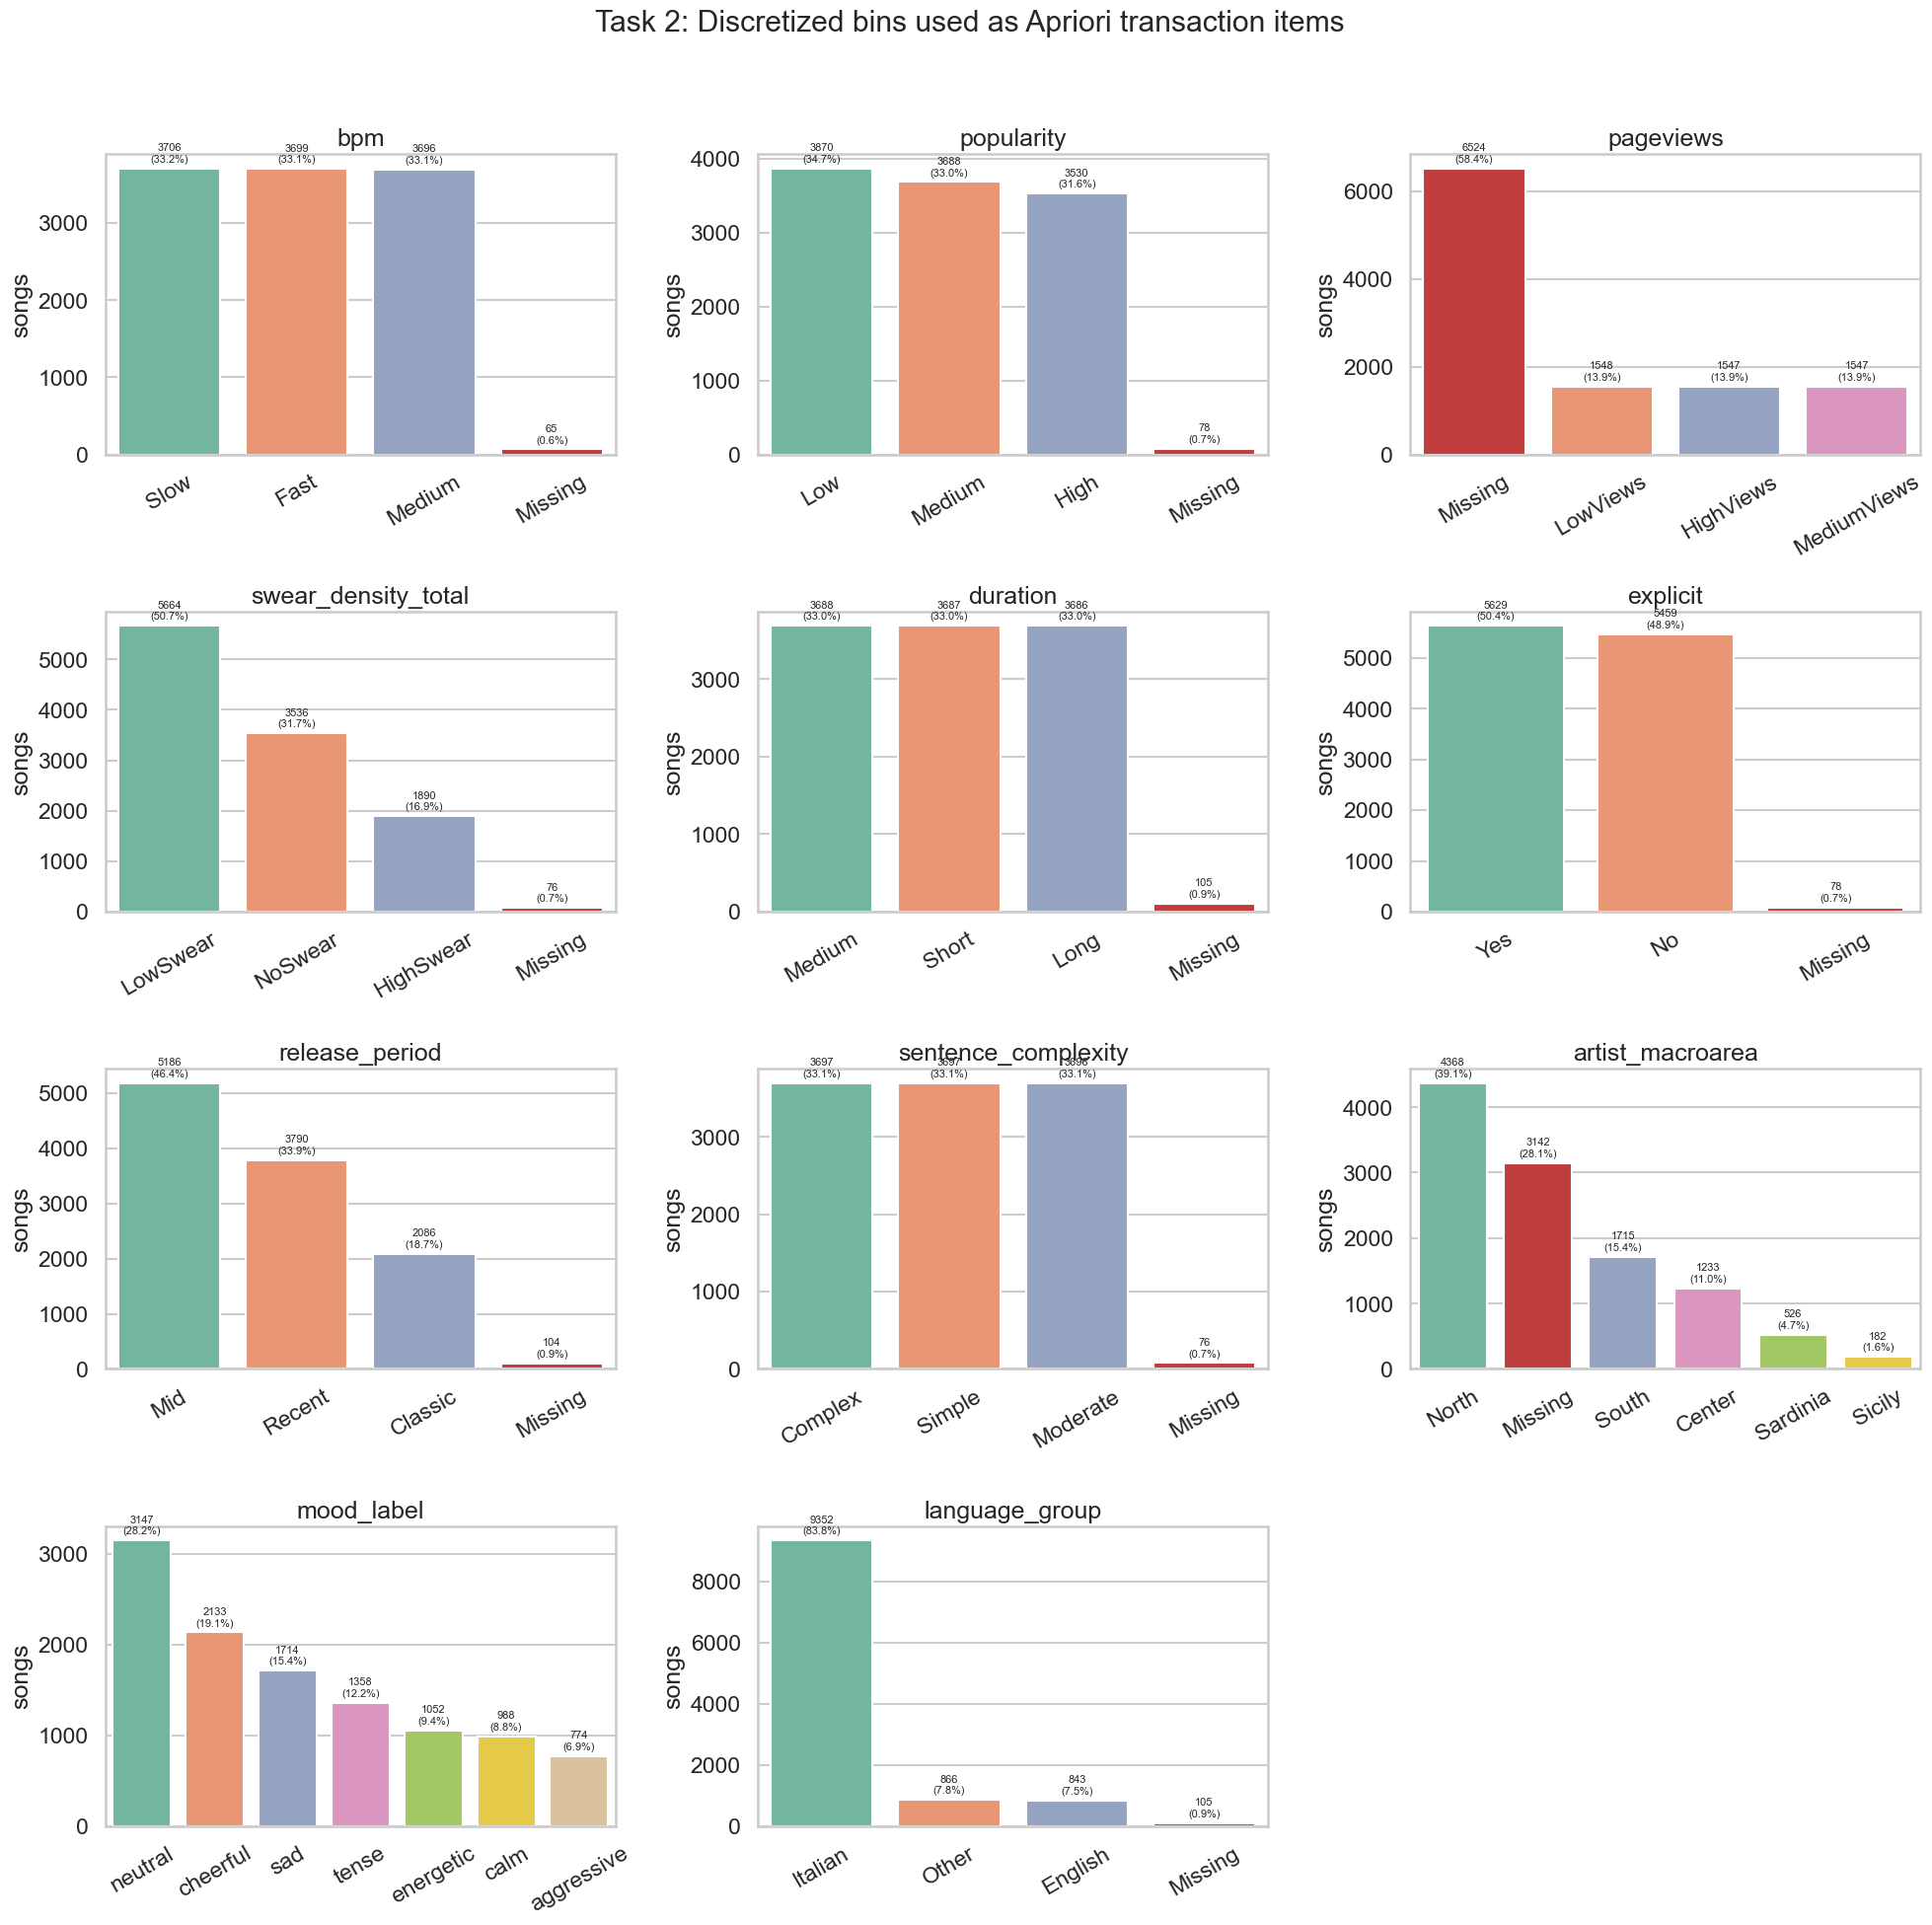

In [ ]:
# Task 2.2 — Visual check of the discretized transaction items

plot_columns = discretized_columns
n_cols = 3
n_rows = int(np.ceil(len(plot_columns) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4.8 * n_rows))
axes = np.array(axes).reshape(-1)

colors = sns.color_palette("Set2", n_colors=len(plot_columns))
missing_color = "#d62728"  # Red for missing values
for i, col in enumerate(plot_columns):
    ax = axes[i]
    counts = (
        apriori_df[col]
        .astype("string")
        .fillna("Missing")
        .value_counts()
        .sort_values(ascending=False)
    )
    sns.barplot(
        x=counts.index.astype(str),
        y=counts.values,
        hue=counts.index.astype(str),
        ax=ax,
        palette=[missing_color if val == "Missing" else colors[i] for i, val in enumerate(counts.index)],
        legend=False
    )
    ax.set_title(col.replace("disc_", ""))
    ax.set_xlabel("")
    ax.set_ylabel("songs")
    ax.tick_params(axis="x", rotation=30)

    total = counts.sum()
    max_count = counts.max()
    for x, y in enumerate(counts.values):
        ax.text(
            x,
            y + max_count * 0.015,
            f"{int(y)}\n({100 * y / total:.1f}%)",
            ha="center",
            va="bottom",
            fontsize=8,
        )

for j in range(len(plot_columns), len(axes)):
    axes[j].axis("off")

fig.suptitle("Task 2: Discretized bins used as Apriori transaction items", y=1.02)
plt.tight_layout()
plt.show()


,metric,value
0,transactions,11166.00
1,candidate_items_after_missing_drop,38.00
2,min_support,0.05
3,min_confidence,0.55
4,min_lift,1.15
5,frequent_itemsets,1171.00
6,association_rules,215.00


,length,n_itemsets,max_support,min_support
0,1,36,0.837543,0.069318
1,2,315,0.426205,0.050063
2,3,603,0.235805,0.050063
3,4,216,0.106126,0.050152
4,5,1,0.051227,0.051227


,itemset_str,support
0,language_group=Italian,0.837543
1,swear_density_total=LowSwear,0.507254
2,explicit=Yes,0.504120
3,explicit=No,0.488895
4,release_period=Mid,0.464446
5,language_group=Italian ∧ swear_density_total=L...,0.426205
6,explicit=No ∧ language_group=Italian,0.421100
7,explicit=Yes ∧ language_group=Italian,0.410084
8,artist_macroarea=North,0.391188
9,language_group=Italian ∧ release_period=Mid,0.383486


,antecedent,consequent,support,confidence,lift,leverage,conviction
0,"explicit=Yes, pageviews=HighViews",popularity=High,0.061,0.714,2.259,0.034,2.394
1,"language_group=Italian, pageviews=HighViews",popularity=High,0.078,0.707,2.235,0.043,2.331
2,pageviews=HighViews,popularity=High,0.097,0.703,2.225,0.054,2.305
3,"pageviews=HighViews, swear_density_total=LowSwear",popularity=High,0.058,0.693,2.192,0.032,2.228
4,pageviews=HighViews,"language_group=Italian, popularity=High",0.078,0.564,2.116,0.041,1.681
5,"pageviews=HighViews, release_period=Mid",popularity=High,0.051,0.641,2.027,0.026,1.904
6,"language_group=Italian, release_period=Classic...",duration=Long,0.051,0.630,1.907,0.024,1.809
7,"release_period=Classic, swear_density_total=Lo...",duration=Long,0.059,0.627,1.899,0.028,1.796
8,"duration=Short, language_group=Italian, popula...",release_period=Recent,0.064,0.645,1.899,0.031,1.859
9,"duration=Short, popularity=High",release_period=Recent,0.076,0.635,1.871,0.035,1.811


/tmp/ipykernel_99833/3436912674.py:189: UserWarning: Glyph 8743 (\N{LOGICAL AND}) missing from font(s) Arial.
  plt.tight_layout()
/home/simone/miniconda3/envs/ML_first_project/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8743 (\N{LOGICAL AND}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


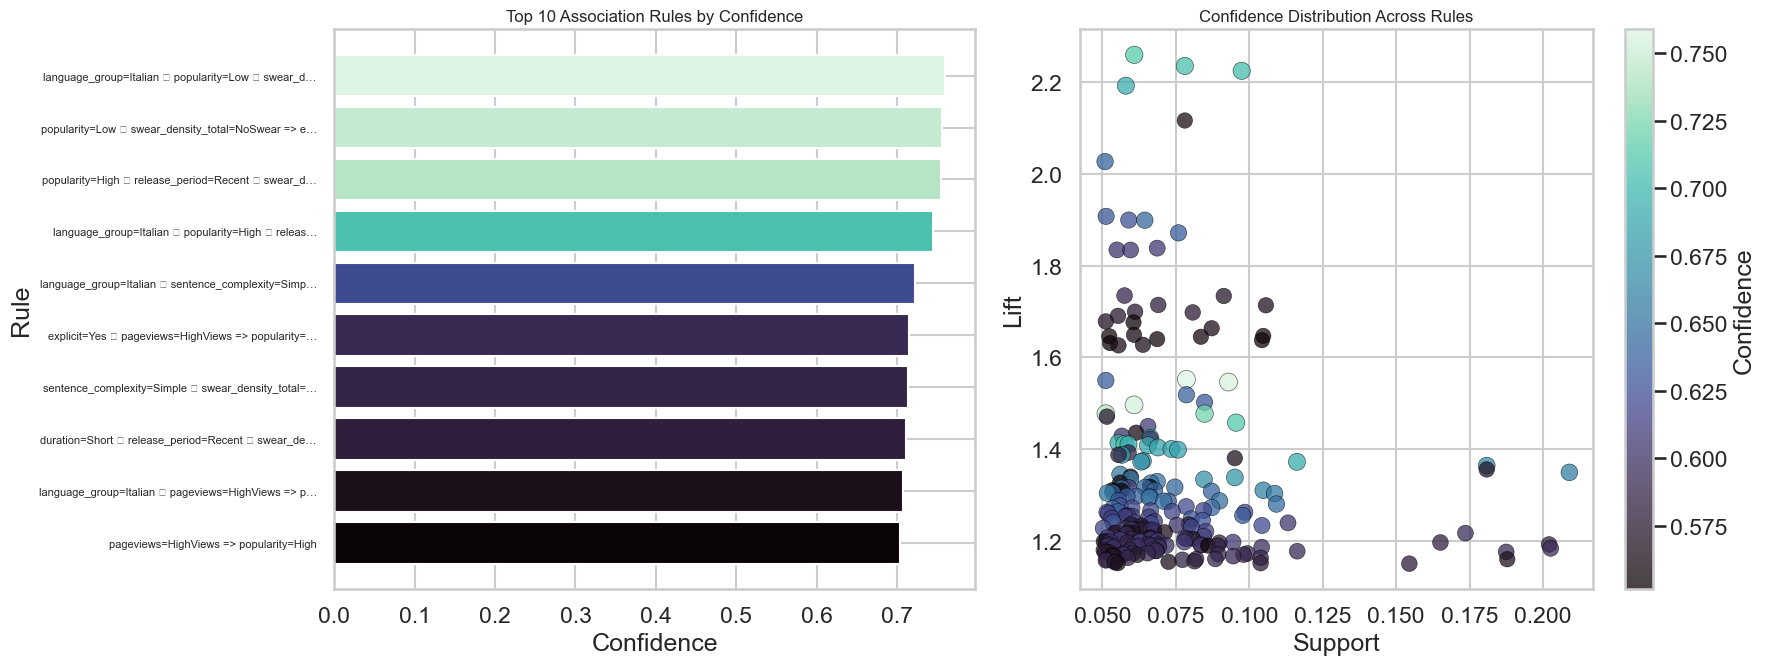

,antecedent,consequent,support,confidence,lift,leverage,conviction
32,"language_group=Italian, popularity=Low, swear_...",explicit=No,0.079,0.759,1.552,0.028,2.120
34,"popularity=Low, swear_density_total=NoSwear",explicit=No,0.093,0.756,1.546,0.033,2.095
37,"popularity=High, release_period=Recent, swear_...",explicit=Yes,0.061,0.754,1.497,0.020,2.019
39,"language_group=Italian, popularity=High, relea...",explicit=Yes,0.051,0.745,1.477,0.017,1.943
38,"language_group=Italian, sentence_complexity=Si...",explicit=No,0.085,0.722,1.478,0.027,1.841
0,"explicit=Yes, pageviews=HighViews",popularity=High,0.061,0.714,2.259,0.034,2.394
41,"sentence_complexity=Simple, swear_density_tota...",explicit=No,0.096,0.713,1.458,0.030,1.779
48,"duration=Short, release_period=Recent, swear_d...",explicit=Yes,0.058,0.711,1.411,0.017,1.718
1,"language_group=Italian, pageviews=HighViews",popularity=High,0.078,0.707,2.235,0.043,2.331
2,pageviews=HighViews,popularity=High,0.097,0.703,2.225,0.054,2.305


Extended confidence view (top 10):
33. language_group=Italian ∧ popularity=Low ∧ swear_density_total=NoSwear => explicit=No | support=0.079, confidence=0.759, lift=1.552
35. popularity=Low ∧ swear_density_total=NoSwear => explicit=No | support=0.093, confidence=0.756, lift=1.546
38. popularity=High ∧ release_period=Recent ∧ swear_density_total=LowSwear => explicit=Yes | support=0.061, confidence=0.754, lift=1.497
40. language_group=Italian ∧ popularity=High ∧ release_period=Recent ∧ swear_density_total=LowSwear => explicit=Yes | support=0.051, confidence=0.745, lift=1.477
39. language_group=Italian ∧ sentence_complexity=Simple ∧ swear_density_total=NoSwear => explicit=No | support=0.085, confidence=0.722, lift=1.478
 1. explicit=Yes ∧ pageviews=HighViews => popularity=High | support=0.061, confidence=0.714, lift=2.259
42. sentence_complexity=Simple ∧ swear_density_total=NoSwear => explicit=No | support=0.096, confidence=0.713, lift=1.458
49. duration=Short ∧ release_period=Recent ∧ swe

In [ ]:
# Task 2.3 - Transaction encoding and association rule mining with mlxtend

from ml_utils.association import row_to_transaction

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules as mlxtend_association_rules


# Build transaction list (one basket per song), then one-hot encode with TransactionEncoder.
transactions = [
    row_to_transaction(apriori_df.loc[idx], discretized_columns)
    for idx in apriori_df.index
]

te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)
transaction_matrix = pd.DataFrame(te_array, columns=te.columns_, index=apriori_df.index).astype(bool)

# Mining parameters.
MIN_SUPPORT = 0.05
MIN_CONFIDENCE = 0.55
MIN_LIFT = 1.15

# Frequent itemsets with Apriori (mlxtend).
frequent_itemsets = apriori(
    transaction_matrix,
    min_support=MIN_SUPPORT,
    use_colnames=True,
).sort_values(["support", "itemsets"], ascending=[False, True]).reset_index(drop=True)

# Rules from frequent itemsets (confidence threshold first), then lift filter.
if frequent_itemsets.empty:
    association_rules = pd.DataFrame(
        columns=[
            "antecedents",
            "consequents",
            "antecedent support",
            "consequent support",
            "support",
            "confidence",
            "lift",
            "leverage",
            "conviction",
        ]
    )
else:
    association_rules = mlxtend_association_rules(
        frequent_itemsets,
        metric="confidence",
        min_threshold=MIN_CONFIDENCE,
        num_itemsets=len(transaction_matrix.index),
    )
    association_rules = association_rules[association_rules["lift"] >= MIN_LIFT].copy()

# Post-process rules for better readability and sorting, only if there are rules to process after filtering.
if not association_rules.empty:
    association_rules["antecedents"] = association_rules["antecedents"].map(frozenset)
    association_rules["consequents"] = association_rules["consequents"].map(frozenset)
    association_rules["antecedents_str"] = association_rules["antecedents"].map(
        lambda x: " ∧ ".join(sorted(x))
    )
    association_rules["consequents_str"] = association_rules["consequents"].map(
        lambda x: " ∧ ".join(sorted(x))
    )
    association_rules["antecedent"] = association_rules["antecedents"].map(
        lambda x: ", ".join(sorted(x))
    )
    association_rules["consequent"] = association_rules["consequents"].map(
        lambda x: ", ".join(sorted(x))
    )
    association_rules["rule_pretty"] = (
        association_rules["antecedents_str"] + " => " + association_rules["consequents_str"]
    )
    association_rules["antecedent_len"] = association_rules["antecedents"].map(len)
    association_rules["consequent_len"] = association_rules["consequents"].map(len)
    association_rules = association_rules.sort_values(
        ["lift", "confidence", "support"],
        ascending=[False, False, False],
    ).reset_index(drop=True)

mining_summary = pd.DataFrame(
    {
        "metric": [
            "transactions",
            "candidate_items_after_missing_drop",
            "min_support",
            "min_confidence",
            "min_lift",
            "frequent_itemsets",
            "association_rules",
        ],
        "value": [
            len(transaction_matrix),
            transaction_matrix.shape[1],
            MIN_SUPPORT,
            MIN_CONFIDENCE,
            MIN_LIFT,
            len(frequent_itemsets),
            len(association_rules),
        ],
    }
)

frequent_itemset_summary = (
    frequent_itemsets.assign(length=frequent_itemsets["itemsets"].map(len))
    .groupby("length")
    .agg(
        n_itemsets=("itemsets", "size"),
        max_support=("support", "max"),
        min_support=("support", "min"),
    )
    .reset_index()
)

display(mining_summary)
display(frequent_itemset_summary)
display(
    frequent_itemsets.assign(itemset_str=frequent_itemsets["itemsets"].map(lambda x: " ∧ ".join(sorted(x))))
    .head(25)[["itemset_str", "support"]]
 )

columns_to_show = [
    "antecedent",
    "consequent",
    "support",
    "confidence",
    "lift",
    "leverage",
    "conviction",
]

if association_rules.empty:
    rules_for_display = pd.DataFrame(columns=columns_to_show)
else:
    rules_for_display = association_rules[columns_to_show].copy()
    for col in ["support", "confidence", "lift", "leverage", "conviction"]:
        rules_for_display[col] = rules_for_display[col].round(3)

display(rules_for_display.head(30))

# Confidence-based association rules representation (top 10, parallel to lift visualization).
if association_rules.empty:
    print("Confidence view: no rules passed the mining thresholds.")
else:
    confidence_rules_display = association_rules.copy()
    top_confidence_rules = confidence_rules_display.nlargest(10, "confidence").copy()
    max_rule_label_chars = 50
    top_confidence_rules["rule_pretty_short"] = top_confidence_rules["rule_pretty"].map(
        lambda s: s if len(s) <= max_rule_label_chars else s[: max_rule_label_chars - 1] + "…"
    )

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))

    confidence_cmap = sns.color_palette("mako", as_cmap=True)
    confidence_values = top_confidence_rules["confidence"].to_numpy()
    confidence_min = confidence_values.min()
    confidence_max = confidence_values.max()
    confidence_norm = mcolors.Normalize(
        vmin=confidence_min,
        vmax=confidence_max if confidence_max > confidence_min else confidence_min + 1e-9,
    )
    axes[0].barh(
        top_confidence_rules["rule_pretty_short"],
        confidence_values,
        color=confidence_cmap(confidence_norm(confidence_values)),
    )
    axes[0].invert_yaxis()
    axes[0].set_title("Top 10 Association Rules by Confidence", fontsize=12)
    axes[0].set_xlabel("Confidence")
    axes[0].set_ylabel("Rule")
    axes[0].tick_params(axis="y", labelsize=8)

    scatter = axes[1].scatter(
        confidence_rules_display["support"],
        confidence_rules_display["lift"],
        c=confidence_rules_display["confidence"],
        s=confidence_rules_display["confidence"] * 220,
        cmap="mako",
        alpha=0.75,
        edgecolor="black",
        linewidth=0.4,
    )
    axes[1].set_title("Confidence Distribution Across Rules", fontsize=12)
    axes[1].set_xlabel("Support")
    axes[1].set_ylabel("Lift")
    cbar = fig.colorbar(scatter, ax=axes[1])
    cbar.set_label("Confidence")

    plt.tight_layout()
    plt.show()

    confidence_table = top_confidence_rules[columns_to_show].copy()
    for col in ["support", "confidence", "lift", "leverage", "conviction"]:
        confidence_table[col] = confidence_table[col].round(3)
    display(confidence_table)

    print("Extended confidence view (top 10):")
    for idx, row in top_confidence_rules.iterrows():
        print(
            f"{idx + 1:>2}. {row['rule_pretty']} | support={row['support']:.3f}, confidence={row['confidence']:.3f}, lift={row['lift']:.3f}"
        )

We also try using a different metric, like lift to see what happens.

/tmp/ipykernel_99833/3450897070.py:67: UserWarning: Glyph 8743 (\N{LOGICAL AND}) missing from font(s) Arial.
  plt.tight_layout()
/home/simone/miniconda3/envs/ML_first_project/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8743 (\N{LOGICAL AND}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


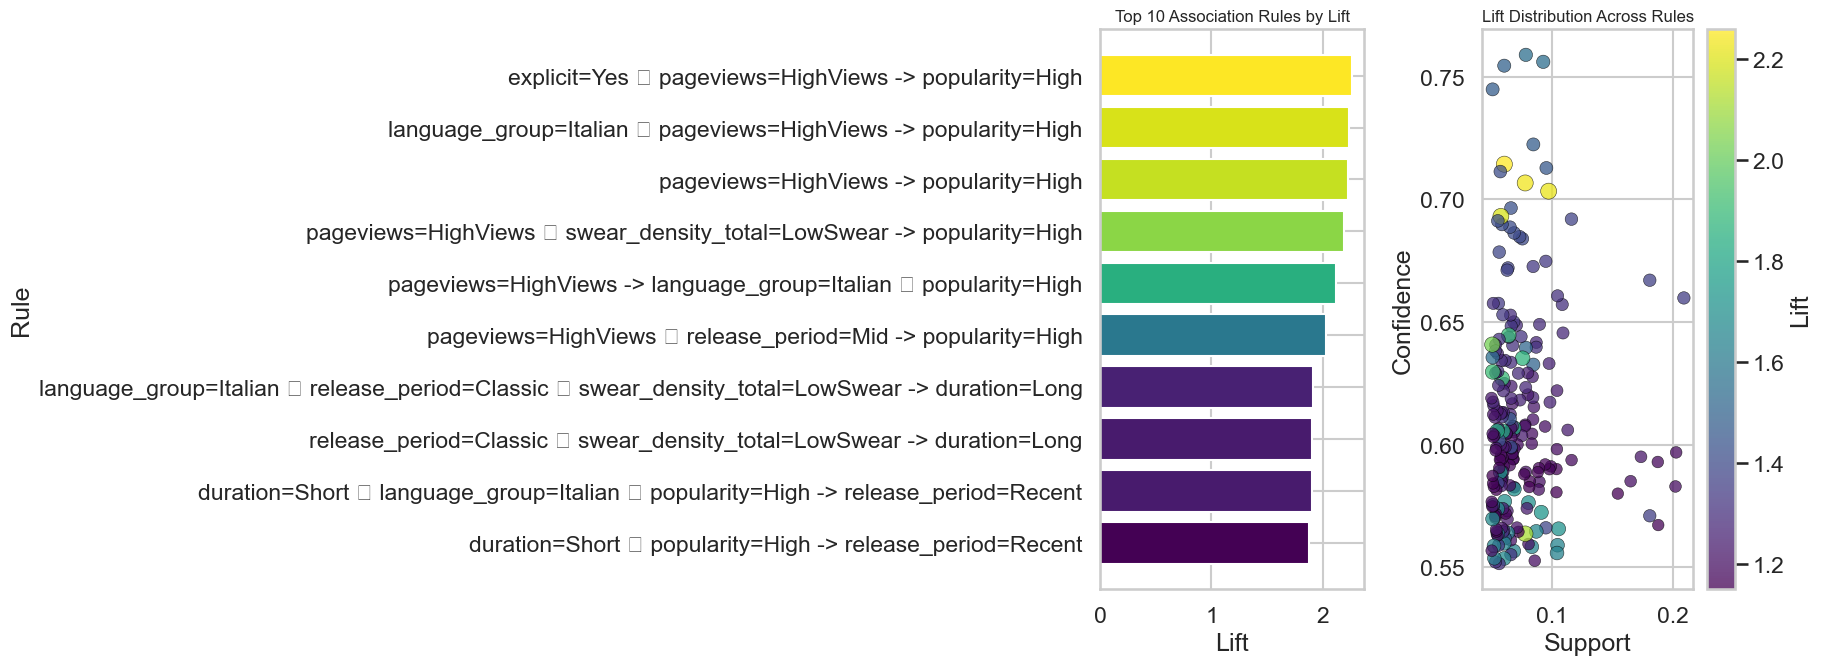

,antecedents,consequents,support,confidence,lift
813,explicit=Yes ∧ pageviews=HighViews,popularity=High,0.061,0.714,2.259
326,language_group=Italian ∧ pageviews=HighViews,popularity=High,0.078,0.707,2.235
122,pageviews=HighViews,popularity=High,0.097,0.703,2.225
1018,pageviews=HighViews ∧ swear_density_total=LowS...,popularity=High,0.058,0.693,2.192
328,pageviews=HighViews,language_group=Italian ∧ popularity=High,0.078,0.564,2.116
1574,pageviews=HighViews ∧ release_period=Mid,popularity=High,0.051,0.641,2.027
1525,language_group=Italian ∧ release_period=Classi...,duration=Long,0.051,0.630,1.907
949,release_period=Classic ∧ swear_density_total=L...,duration=Long,0.059,0.627,1.899
672,duration=Short ∧ language_group=Italian ∧ popu...,release_period=Recent,0.064,0.645,1.899
364,duration=Short ∧ popularity=High,release_period=Recent,0.076,0.635,1.871


Extended lift view (top 10):
 1. antecedents=explicit=Yes ∧ pageviews=HighViews | consequents=popularity=High | support=0.061, confidence=0.714, lift=2.259
 2. antecedents=language_group=Italian ∧ pageviews=HighViews | consequents=popularity=High | support=0.078, confidence=0.707, lift=2.235
 3. antecedents=pageviews=HighViews | consequents=popularity=High | support=0.097, confidence=0.703, lift=2.225
 4. antecedents=pageviews=HighViews ∧ swear_density_total=LowSwear | consequents=popularity=High | support=0.058, confidence=0.693, lift=2.192
 5. antecedents=pageviews=HighViews | consequents=language_group=Italian ∧ popularity=High | support=0.078, confidence=0.564, lift=2.116
 6. antecedents=pageviews=HighViews ∧ release_period=Mid | consequents=popularity=High | support=0.051, confidence=0.641, lift=2.027
 7. antecedents=language_group=Italian ∧ release_period=Classic ∧ swear_density_total=LowSwear | consequents=duration=Long | support=0.051, confidence=0.630, lift=1.907
 8. anteceden

In [ ]:
rules_lift = mlxtend_association_rules(
    frequent_itemsets,
    metric="lift",
    min_threshold=MIN_LIFT,
    num_itemsets=len(transaction_matrix.index),
)
rules_lift = rules_lift[rules_lift["confidence"] >= MIN_CONFIDENCE].copy()

# Lift-based association rules representation
if rules_lift.empty:
    print("No rules satisfied the lift/confidence thresholds.")
else:
    rules_lift_display = rules_lift.copy()
    rules_lift_display["antecedent_label"] = rules_lift_display["antecedents"].apply(
        lambda x: " ∧ ".join(sorted(list(x)))
    )
    rules_lift_display["consequent_label"] = rules_lift_display["consequents"].apply(
        lambda x: " ∧ ".join(sorted(list(x)))
    )
    rules_lift_display["rule_label"] = (
        rules_lift_display["antecedent_label"]
        + " -> "
        + rules_lift_display["consequent_label"]
    )

    top_n = min(10, len(rules_lift_display))
    top_lift_rules = rules_lift_display.nlargest(top_n, "lift").copy()

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))

    # 1) Top lift rules (bar chart)
    lift_cmap = sns.color_palette("viridis", as_cmap=True)
    lift_values = top_lift_rules["lift"].to_numpy()
    lift_min = lift_values.min()
    lift_max = lift_values.max()
    lift_norm = mcolors.Normalize(
        vmin=lift_min,
        vmax=lift_max if lift_max > lift_min else lift_min + 1e-9,
    )
    axes[0].barh(
        top_lift_rules["rule_label"],
        lift_values,
        color=lift_cmap(lift_norm(lift_values)),
    )
    axes[0].invert_yaxis()
    axes[0].set_title(f"Top {top_n} Association Rules by Lift", fontsize=12)
    axes[0].set_xlabel("Lift")
    axes[0].set_ylabel("Rule")

    # 2) Rule landscape: support vs confidence, color = lift
    scatter = axes[1].scatter(
        rules_lift_display["support"],
        rules_lift_display["confidence"],
        c=rules_lift_display["lift"],
        s=rules_lift_display["lift"] * 60,
        cmap="viridis",
        alpha=0.75,
        edgecolor="black",
        linewidth=0.4,
    )
    axes[1].set_title("Lift Distribution Across Rules", fontsize=12)
    axes[1].set_xlabel("Support")
    axes[1].set_ylabel("Confidence")
    cbar = fig.colorbar(scatter, ax=axes[1])
    cbar.set_label("Lift")

    plt.tight_layout()
    plt.show()

    top_lift_table = top_lift_rules[[
        "antecedent_label",
        "consequent_label",
        "support",
        "confidence",
        "lift",
    ]].rename(
        columns={
            "antecedent_label": "antecedents",
            "consequent_label": "consequents",
        }
    )
    for col in ["support", "confidence", "lift"]:
        top_lift_table[col] = top_lift_table[col].round(3)
    display(top_lift_table)

    print("Extended lift view (top 10):")
    for idx, row in top_lift_rules.reset_index(drop=True).iterrows():
        print(
            f"{idx + 1:>2}. antecedents={row['antecedent_label']} | consequents={row['consequent_label']} | support={row['support']:.3f}, confidence={row['confidence']:.3f}, lift={row['lift']:.3f}"
        )

In [ ]:
# Visual confrontation: Top-10 confidence-based rules vs Top-10 lift-based rules (two tables)

if "top_confidence_rules" not in locals() or "top_lift_rules" not in locals():
    print("Missing required variables: run the cells that generate top_confidence_rules and top_lift_rules first.")
else:
    def _items_to_text(items):
        return " ∧ ".join(sorted(list(items)))

    # --- Confidence table ---
    conf_top10 = top_confidence_rules.nlargest(10, "confidence").copy()
    conf_top10["antecedents_text"] = conf_top10["antecedents"].apply(_items_to_text)
    conf_top10["consequents_text"] = conf_top10["consequents"].apply(_items_to_text)
    conf_top10["rule_key"] = list(zip(conf_top10["antecedents_text"], conf_top10["consequents_text"]))

    conf_view = conf_top10[["antecedents_text", "consequents_text", "support", "confidence", "lift"]].copy()
    conf_view = conf_view.rename(
        columns={
            "antecedents_text": "antecedents",
            "consequents_text": "consequents",
            }
    )
    conf_view.insert(0, "rank_confidence", range(1, len(conf_view) + 1))

    # --- Lift table ---
    lift_top10 = top_lift_rules.nlargest(10, "lift").copy()
    lift_top10["antecedents_text"] = lift_top10["antecedents"].apply(_items_to_text)
    lift_top10["consequents_text"] = lift_top10["consequents"].apply(_items_to_text)
    lift_top10["rule_key"] = list(zip(lift_top10["antecedents_text"], lift_top10["consequents_text"]))

    lift_view = lift_top10[["antecedents_text", "consequents_text", "support", "confidence", "lift"]].copy()
    lift_view = lift_view.rename(
        columns={
            "antecedents_text": "antecedents",
            "consequents_text": "consequents",
        }
    )
    lift_view.insert(0, "rank_lift", range(1, len(lift_view) + 1))

    # Cross-reference (shared rules across top-10 lists)
    conf_rule_set = set(conf_top10["rule_key"])
    lift_rule_set = set(lift_top10["rule_key"])
    conf_view["in_lift_top10"] = conf_top10["rule_key"].isin(lift_rule_set)
    lift_view["in_conf_top10"] = lift_top10["rule_key"].isin(conf_rule_set)

    for c in ["support", "confidence", "lift"]:
        conf_view[c] = conf_view[c].round(3)
        lift_view[c] = lift_view[c].round(3)

    print("Top 10 rules by CONFIDENCE")
    display(conf_view)

    print("Top 10 rules by LIFT")
    display(lift_view)

Top 10 rules by CONFIDENCE


,rank_confidence,antecedents,consequents,support,confidence,lift,in_lift_top10
32,1,language_group=Italian ∧ popularity=Low ∧ swea...,explicit=No,0.079,0.759,1.552,False
34,2,popularity=Low ∧ swear_density_total=NoSwear,explicit=No,0.093,0.756,1.546,False
37,3,popularity=High ∧ release_period=Recent ∧ swea...,explicit=Yes,0.061,0.754,1.497,False
39,4,language_group=Italian ∧ popularity=High ∧ rel...,explicit=Yes,0.051,0.745,1.477,False
38,5,language_group=Italian ∧ sentence_complexity=S...,explicit=No,0.085,0.722,1.478,False
0,6,explicit=Yes ∧ pageviews=HighViews,popularity=High,0.061,0.714,2.259,True
41,7,sentence_complexity=Simple ∧ swear_density_tot...,explicit=No,0.096,0.713,1.458,False
48,8,duration=Short ∧ release_period=Recent ∧ swear...,explicit=Yes,0.058,0.711,1.411,False
1,9,language_group=Italian ∧ pageviews=HighViews,popularity=High,0.078,0.707,2.235,True
2,10,pageviews=HighViews,popularity=High,0.097,0.703,2.225,True


Top 10 rules by LIFT


,rank_lift,antecedents,consequents,support,confidence,lift,in_conf_top10
813,1,explicit=Yes ∧ pageviews=HighViews,popularity=High,0.061,0.714,2.259,True
326,2,language_group=Italian ∧ pageviews=HighViews,popularity=High,0.078,0.707,2.235,True
122,3,pageviews=HighViews,popularity=High,0.097,0.703,2.225,True
1018,4,pageviews=HighViews ∧ swear_density_total=LowS...,popularity=High,0.058,0.693,2.192,False
328,5,pageviews=HighViews,language_group=Italian ∧ popularity=High,0.078,0.564,2.116,False
1574,6,pageviews=HighViews ∧ release_period=Mid,popularity=High,0.051,0.641,2.027,False
1525,7,language_group=Italian ∧ release_period=Classi...,duration=Long,0.051,0.630,1.907,False
949,8,release_period=Classic ∧ swear_density_total=L...,duration=Long,0.059,0.627,1.899,False
672,9,duration=Short ∧ language_group=Italian ∧ popu...,release_period=Recent,0.064,0.645,1.899,False
364,10,duration=Short ∧ popularity=High,release_period=Recent,0.076,0.635,1.871,False


Drop explicit and language from the rule mining, as they are not relevant for the pattern mining and may introduce noise due to their high cardinality and potential redundancy with other features. We prioritize lift based analysis as the rules generated with confidence as metric are not very interesting, as they mostly capture very high confidence rules with low lift, which are not very informative for our purposes. By using lift, we can identify rules that have a stronger association than expected by chance, which can provide more actionable insights for feature engineering.

,metric,value
0,transactions,11166.00
1,items_after_drop,33.00
2,min_support,0.05
3,min_confidence,0.55
4,min_lift,1.15
5,frequent_itemsets,424.00
6,rules,23.00


/tmp/ipykernel_99833/2121005504.py:112: UserWarning: Glyph 8743 (\N{LOGICAL AND}) missing from font(s) Arial.
  plt.tight_layout()
/home/simone/miniconda3/envs/ML_first_project/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8743 (\N{LOGICAL AND}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


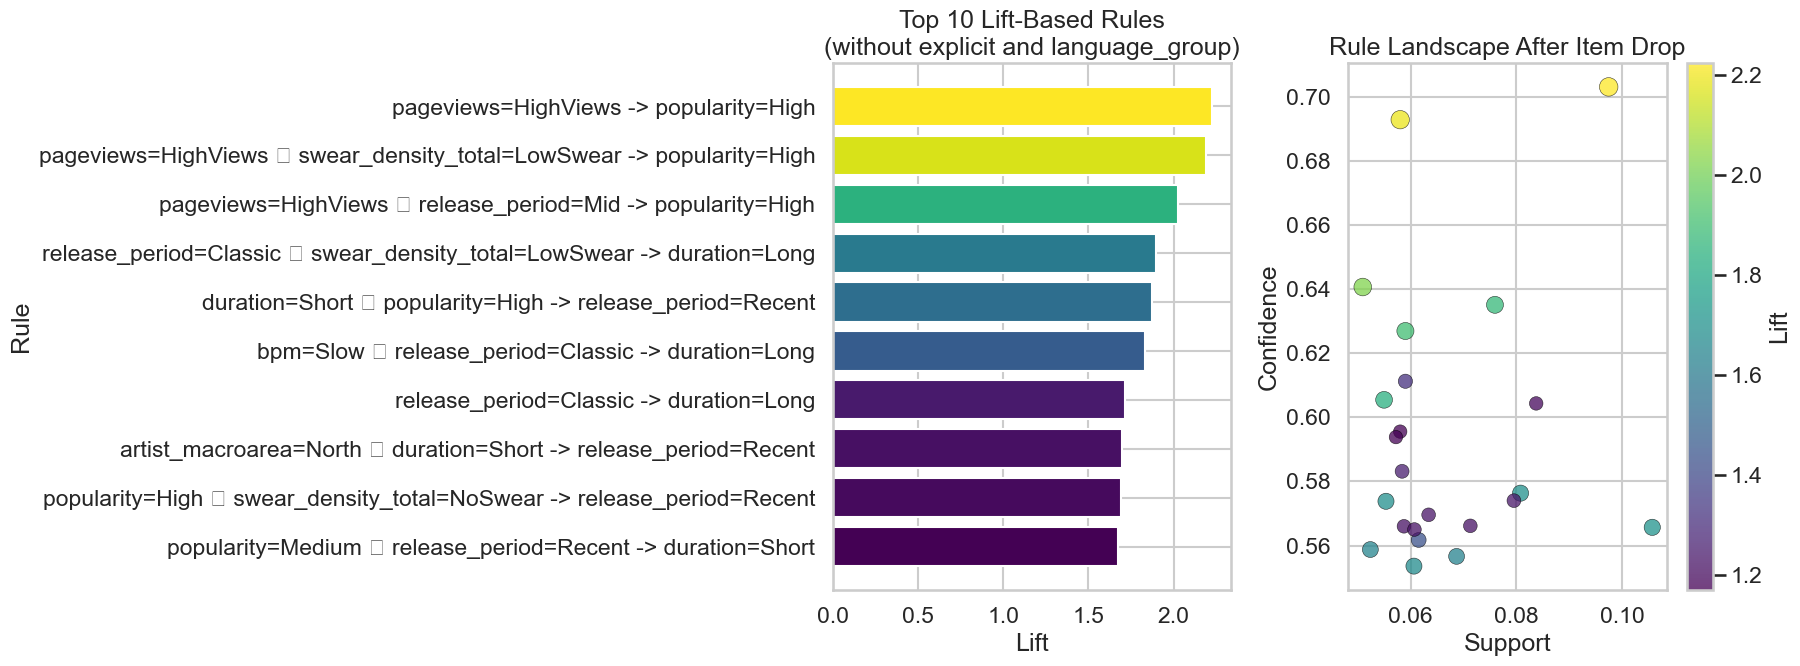

,antecedents,consequents,support,confidence,lift
0,pageviews=HighViews,popularity=High,0.097,0.703,2.225
1,pageviews=HighViews ∧ swear_density_total=LowS...,popularity=High,0.058,0.693,2.192
2,pageviews=HighViews ∧ release_period=Mid,popularity=High,0.051,0.641,2.027
3,release_period=Classic ∧ swear_density_total=L...,duration=Long,0.059,0.627,1.899
4,duration=Short ∧ popularity=High,release_period=Recent,0.076,0.635,1.871
5,bpm=Slow ∧ release_period=Classic,duration=Long,0.055,0.606,1.834
6,release_period=Classic,duration=Long,0.106,0.566,1.714
7,artist_macroarea=North ∧ duration=Short,release_period=Recent,0.081,0.576,1.698
8,popularity=High ∧ swear_density_total=NoSwear,release_period=Recent,0.055,0.574,1.691
9,popularity=Medium ∧ release_period=Recent,duration=Short,0.061,0.554,1.676


Top lift-based rules after dropping explicit and language_group:
 1. pageviews=HighViews -> popularity=High | support=0.097, confidence=0.703, lift=2.225
 2. pageviews=HighViews ∧ swear_density_total=LowSwear -> popularity=High | support=0.058, confidence=0.693, lift=2.192
 3. pageviews=HighViews ∧ release_period=Mid -> popularity=High | support=0.051, confidence=0.641, lift=2.027
 4. release_period=Classic ∧ swear_density_total=LowSwear -> duration=Long | support=0.059, confidence=0.627, lift=1.899
 5. duration=Short ∧ popularity=High -> release_period=Recent | support=0.076, confidence=0.635, lift=1.871
 6. bpm=Slow ∧ release_period=Classic -> duration=Long | support=0.055, confidence=0.606, lift=1.834
 7. release_period=Classic -> duration=Long | support=0.106, confidence=0.566, lift=1.714
 8. artist_macroarea=North ∧ duration=Short -> release_period=Recent | support=0.081, confidence=0.576, lift=1.698
 9. popularity=High ∧ swear_density_total=NoSwear -> release_period=Recent | supp

In [ ]:
# Re-mine association rules after dropping explicit and language_group items
drop_prefixes = ("explicit=", "language_group=")

transaction_matrix_reduced = transaction_matrix.loc[
    :,
    ~transaction_matrix.columns.str.startswith(drop_prefixes),
].copy()

min_support = MIN_SUPPORT if "MIN_SUPPORT" in locals() else 0.05
min_confidence = MIN_CONFIDENCE if "MIN_CONFIDENCE" in locals() else 0.55
min_lift = MIN_LIFT if "MIN_LIFT" in locals() else 1.15

frequent_itemsets_reduced = apriori(
    transaction_matrix_reduced,
    min_support=min_support,
    use_colnames=True,
).sort_values(["support", "itemsets"], ascending=[False, True]).reset_index(drop=True)

if frequent_itemsets_reduced.empty:
    rules_lift_reduced = pd.DataFrame()
    print("No frequent itemsets found after dropping explicit and language_group.")
else:
    rules_lift_reduced = mlxtend_association_rules(
        frequent_itemsets_reduced,
        metric="lift",
        min_threshold=min_lift,
        num_itemsets=len(transaction_matrix_reduced),
    )
    rules_lift_reduced = rules_lift_reduced[
        rules_lift_reduced["confidence"] >= min_confidence
    ].copy()

if rules_lift_reduced.empty:
    print("No rules satisfied the lift/confidence thresholds after dropping explicit and language_group.")
else:
    rules_lift_reduced["antecedent_label"] = rules_lift_reduced["antecedents"].apply(
        lambda x: " ∧ ".join(sorted(x))
    )
    rules_lift_reduced["consequent_label"] = rules_lift_reduced["consequents"].apply(
        lambda x: " ∧ ".join(sorted(x))
    )
    rules_lift_reduced["rule_label"] = (
        rules_lift_reduced["antecedent_label"] + " -> " + rules_lift_reduced["consequent_label"]
    )
    rules_lift_reduced = rules_lift_reduced.sort_values(
        ["lift", "confidence", "support"],
        ascending=[False, False, False],
    ).reset_index(drop=True)

    mining_summary_reduced = pd.DataFrame(
        {
            "metric": [
                "transactions",
                "items_after_drop",
                "min_support",
                "min_confidence",
                "min_lift",
                "frequent_itemsets",
                "rules",
            ],
            "value": [
                len(transaction_matrix_reduced),
                transaction_matrix_reduced.shape[1],
                min_support,
                min_confidence,
                min_lift,
                len(frequent_itemsets_reduced),
                len(rules_lift_reduced),
            ],
        }
    )
    display(mining_summary_reduced)

    top_n = min(10, len(rules_lift_reduced))
    top_lift_rules_reduced = rules_lift_reduced.head(top_n).copy()

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))

    lift_values = top_lift_rules_reduced["lift"].to_numpy()
    lift_norm = mcolors.Normalize(
        vmin=lift_values.min(),
        vmax=lift_values.max() if lift_values.max() > lift_values.min() else lift_values.min() + 1e-9,
    )
    lift_cmap = sns.color_palette("viridis", as_cmap=True)

    axes[0].barh(
        top_lift_rules_reduced["rule_label"],
        top_lift_rules_reduced["lift"],
        color=lift_cmap(lift_norm(lift_values)),
    )
    axes[0].invert_yaxis()
    axes[0].set_title(f"Top {top_n} Lift-Based Rules\n(without explicit and language_group)")
    axes[0].set_xlabel("Lift")
    axes[0].set_ylabel("Rule")

    scatter_reduced = axes[1].scatter(
        rules_lift_reduced["support"],
        rules_lift_reduced["confidence"],
        c=rules_lift_reduced["lift"],
        s=rules_lift_reduced["lift"] * 80,
        cmap="viridis",
        alpha=0.75,
        edgecolor="black",
        linewidth=0.4,
    )
    axes[1].set_title("Rule Landscape After Item Drop")
    axes[1].set_xlabel("Support")
    axes[1].set_ylabel("Confidence")
    cbar = fig.colorbar(scatter_reduced, ax=axes[1])
    cbar.set_label("Lift")

    plt.tight_layout()
    plt.show()

    rules_lift_reduced_display = top_lift_rules_reduced[
        ["antecedent_label", "consequent_label", "support", "confidence", "lift"]
    ].rename(
        columns={
            "antecedent_label": "antecedents",
            "consequent_label": "consequents",
        }
    )
    for col in ["support", "confidence", "lift"]:
        rules_lift_reduced_display[col] = rules_lift_reduced_display[col].round(3)

    display(rules_lift_reduced_display)

    print("Top lift-based rules after dropping explicit and language_group:")
    for i, row in top_lift_rules_reduced.reset_index(drop=True).iterrows():
        print(
            f"{i + 1:>2}. {row['rule_label']} | "
            f"support={row['support']:.3f}, confidence={row['confidence']:.3f}, lift={row['lift']:.3f}"
        )

## Retrieving The Most Interesting Association Rules

After comparing confidence-based rules, lift-based rules, and the reduced mining setup without `explicit` and `language_group`, we adopt the reduced lift-based mining result as the canonical source for interpretation. This choice is more defensible because it removes high-frequency shortcut items and keeps rules that are more likely to reflect non-trivial co-occurrence structure.

In this step, we do not simply take the top rules by a single metric. Instead, we apply a staged selection process designed to balance interpretability, usefulness, and statistical interest:

- keep only rules whose consequents are relevant for downstream analysis (`popularity`, `release_period`, `duration`, `mood_label`, `swear_density_total`)
- enforce minimum thresholds on support, confidence, lift, and leverage
- limit antecedent complexity to short and interpretable rules
- compute a novelty measure, defined as `confidence - consequent_support`, to capture how much the antecedent improves over the baseline rate of the consequent
- prune redundant longer rules when they do not add enough confidence compared with a simpler subset rule
- rank surviving rules with a composite interestingness score that combines lift, novelty, leverage, and support
- diversify the final shortlist so it is not dominated by multiple near-duplicate rules with the same consequent

The final output is therefore a compact set of rules that are more suitable for discussion in the report and more realistic candidates for later unsupervised learning.

In [ ]:
# Task 2.4 — Retrieve interesting association rules from the reduced lift-based mining

if "rules_lift_reduced" not in locals() or rules_lift_reduced.empty:
    print("No reduced lift-based rules available. Run the previous reduced mining cell first.")
else:
    canonical_rules = rules_lift_reduced.copy()
    n_transactions_reduced = len(transaction_matrix_reduced)

    target_prefixes = (
        "popularity=",
        "release_period=",
        "duration=",
        "mood_label=",
        "swear_density_total=",
    )

    min_support_interesting = 0.03
    min_confidence_interesting = 0.45
    min_lift_interesting = 1.20
    min_leverage_interesting = 0.005
    max_antecedent_len = 2
    min_confidence_gain = 0.05
    max_rules_per_consequent = 3

    def items_to_text(items):
        return " ∧ ".join(sorted(items))

    def has_target_consequent(consequents):
        return any(any(item.startswith(prefix) for prefix in target_prefixes) for item in consequents)

    def zscore_series(series):
        std = series.std(ddof=0)
        if pd.isna(std) or std == 0:
            return pd.Series(0.0, index=series.index)
        return (series - series.mean()) / std

    interesting_rules = canonical_rules.copy()
    interesting_rules["antecedent_len"] = interesting_rules["antecedents"].map(len)
    interesting_rules["consequent_len"] = interesting_rules["consequents"].map(len)
    interesting_rules["antecedents_text"] = interesting_rules["antecedents"].map(items_to_text)
    interesting_rules["consequents_text"] = interesting_rules["consequents"].map(items_to_text)
    interesting_rules["support_count"] = (interesting_rules["support"] * n_transactions_reduced).round().astype(int)
    interesting_rules["novelty"] = interesting_rules["confidence"] - interesting_rules["consequent support"]

    interesting_rules = interesting_rules[
        interesting_rules["consequents"].map(has_target_consequent)
        & (interesting_rules["support"] >= min_support_interesting)
        & (interesting_rules["confidence"] >= min_confidence_interesting)
        & (interesting_rules["lift"] >= min_lift_interesting)
        & (interesting_rules["leverage"] >= min_leverage_interesting)
        & (interesting_rules["antecedent_len"] <= max_antecedent_len)
    ].copy()

    if interesting_rules.empty:
        print("No rules passed the interestingness filters.")
    else:
        interesting_rules = interesting_rules.sort_values(
            ["consequents_text", "antecedent_len", "confidence", "lift", "support"],
            ascending=[True, True, False, False, False],
        ).reset_index(drop=True)

        confidence_lookup = {
            (frozenset(row["antecedents"]), frozenset(row["consequents"])): float(row["confidence"])
            for _, row in interesting_rules.iterrows()
        }

        redundancy_flags = []
        retention_reasons = []
        confidence_gains = []

        for _, row in interesting_rules.iterrows():
            antecedents = frozenset(row["antecedents"])
            consequents = frozenset(row["consequents"])

            if len(antecedents) <= 1:
                redundancy_flags.append(False)
                retention_reasons.append("base rule")
                confidence_gains.append(np.nan)
                continue

            subset_confidences = []
            for item in antecedents:
                subset = antecedents - {item}
                key = (subset, consequents)
                if key in confidence_lookup:
                    subset_confidences.append(confidence_lookup[key])

            if subset_confidences:
                best_subset_confidence = max(subset_confidences)
                confidence_gain = float(row["confidence"] - best_subset_confidence)
                is_redundant = confidence_gain < min_confidence_gain
                redundancy_flags.append(is_redundant)
                retention_reasons.append(
                    "adds signal over simpler rule" if not is_redundant else "redundant vs simpler rule"
                )
                confidence_gains.append(confidence_gain)
            else:
                redundancy_flags.append(False)
                retention_reasons.append("no simpler comparator found")
                confidence_gains.append(np.nan)

        interesting_rules["is_redundant"] = redundancy_flags
        interesting_rules["confidence_gain_vs_subset"] = confidence_gains
        interesting_rules["retention_reason"] = retention_reasons

        pruned_rules = interesting_rules.loc[~interesting_rules["is_redundant"]].copy()

        if pruned_rules.empty:
            print("All candidate rules were pruned as redundant. Consider relaxing the confidence-gain threshold.")
        else:
            pruned_rules["interestingness_score"] = (
                zscore_series(pruned_rules["lift"])
                + zscore_series(pruned_rules["novelty"])
                + zscore_series(pruned_rules["leverage"])
                + 0.5 * zscore_series(pruned_rules["support"])
            )

            pruned_rules = pruned_rules.sort_values(
                ["interestingness_score", "lift", "confidence", "support"],
                ascending=[False, False, False, False],
            ).reset_index(drop=True)

            diversified_rows = []
            consequent_counts = {}
            seen_rule_signatures = set()

            for _, row in pruned_rules.iterrows():
                consequent_text = row["consequents_text"]
                antecedent_text = row["antecedents_text"]
                signature = (antecedent_text, consequent_text)

                if signature in seen_rule_signatures:
                    continue
                if consequent_counts.get(consequent_text, 0) >= max_rules_per_consequent:
                    continue

                diversified_rows.append(row)
                seen_rule_signatures.add(signature)
                consequent_counts[consequent_text] = consequent_counts.get(consequent_text, 0) + 1

            final_interesting_rules = pd.DataFrame(diversified_rows).reset_index(drop=True)

            retrieval_summary = pd.DataFrame(
                {
                    "stage": [
                        "reduced lift-based rules",
                        "after target/quality filters",
                        "after redundancy pruning",
                        "final diversified shortlist",
                    ],
                    "n_rules": [
                        len(canonical_rules),
                        len(interesting_rules),
                        len(pruned_rules),
                        len(final_interesting_rules),
                    ],
                }
            )

            display(retrieval_summary)

            final_rules_view = final_interesting_rules[
                [
                    "antecedents_text",
                    "consequents_text",
                    "support",
                    "support_count",
                    "confidence",
                    "consequent support",
                    "novelty",
                    "lift",
                    "leverage",
                    "antecedent_len",
                    "confidence_gain_vs_subset",
                    "interestingness_score",
                    "retention_reason",
                ]
            ].rename(
                columns={
                    "antecedents_text": "antecedents",
                    "consequents_text": "consequents",
                    "consequent support": "consequent_support",
                }
            )

            for col in [
                "support",
                "confidence",
                "consequent_support",
                "novelty",
                "lift",
                "leverage",
                "confidence_gain_vs_subset",
                "interestingness_score",
            ]:
                final_rules_view[col] = final_rules_view[col].round(3)

            display(final_rules_view)

            print("Interesting rule shortlist:")
            for idx, row in final_rules_view.reset_index(drop=True).iterrows():
                print(
                    f"{idx + 1:>2}. antecedents={row['antecedents']} | consequents={row['consequents']} | "
                    f"support={row['support']:.3f}, confidence={row['confidence']:.3f}, lift={row['lift']:.3f}, novelty={row['novelty']:.3f}"
                )

            interesting_rules_selected = final_interesting_rules.copy()

,stage,n_rules
0,reduced lift-based rules,23
1,after target/quality filters,19
2,after redundancy pruning,16
3,final diversified shortlist,10


,antecedents,consequents,support,support_count,confidence,consequent_support,novelty,lift,leverage,antecedent_len,confidence_gain_vs_subset,interestingness_score,retention_reason
0,pageviews=HighViews,popularity=High,0.097,1088,0.703,0.316,0.387,2.225,0.054,1,NaN,7.890,base rule
1,release_period=Classic,duration=Long,0.106,1180,0.566,0.330,0.236,1.714,0.044,1,NaN,3.907,base rule
2,duration=Short ∧ popularity=High,release_period=Recent,0.076,848,0.635,0.339,0.296,1.871,0.035,2,NaN,3.444,no simpler comparator found
3,release_period=Classic ∧ swear_density_total=L...,duration=Long,0.059,659,0.627,0.330,0.297,1.899,0.028,2,0.061,2.382,adds signal over simpler rule
4,artist_macroarea=North ∧ duration=Short,release_period=Recent,0.081,902,0.576,0.339,0.237,1.698,0.033,2,NaN,2.163,no simpler comparator found
5,artist_macroarea=North ∧ popularity=High,release_period=Recent,0.069,767,0.557,0.339,0.217,1.640,0.027,2,NaN,0.813,no simpler comparator found
6,popularity=Medium ∧ release_period=Recent,duration=Short,0.061,677,0.554,0.330,0.223,1.676,0.024,2,NaN,0.547,no simpler comparator found
7,pageviews=HighViews,release_period=Mid,0.080,888,0.574,0.464,0.110,1.236,0.015,1,NaN,-2.367,base rule
8,bpm=Fast ∧ duration=Long,release_period=Mid,0.059,659,0.611,0.464,0.147,1.316,0.014,2,NaN,-2.433,no simpler comparator found
9,artist_macroarea=North ∧ popularity=Low,release_period=Mid,0.071,796,0.566,0.464,0.102,1.219,0.013,2,NaN,-2.986,no simpler comparator found


Interesting rule shortlist:
 1. antecedents=pageviews=HighViews | consequents=popularity=High | support=0.097, confidence=0.703, lift=2.225, novelty=0.387
 2. antecedents=release_period=Classic | consequents=duration=Long | support=0.106, confidence=0.566, lift=1.714, novelty=0.236
 3. antecedents=duration=Short ∧ popularity=High | consequents=release_period=Recent | support=0.076, confidence=0.635, lift=1.871, novelty=0.296
 4. antecedents=release_period=Classic ∧ swear_density_total=LowSwear | consequents=duration=Long | support=0.059, confidence=0.627, lift=1.899, novelty=0.297
 5. antecedents=artist_macroarea=North ∧ duration=Short | consequents=release_period=Recent | support=0.081, confidence=0.576, lift=1.698, novelty=0.237
 6. antecedents=artist_macroarea=North ∧ popularity=High | consequents=release_period=Recent | support=0.069, confidence=0.557, lift=1.640, novelty=0.217
 7. antecedents=popularity=Medium ∧ release_period=Recent | consequents=duration=Short | support=0.061, c

## Task 3 Preparation: Using Association Rules For Clustering

The rule-mining step is not used here as a replacement for clustering. Instead, it is used as a structured feature-selection layer before the unsupervised step. The goal is to convert only the most interpretable and sufficiently prevalent rule antecedents into candidate binary indicators, while leaving overly sparse or redundant rules for interpretation only.

This preparation step follows three principles:

- keep rule-derived indicators only when they have enough prevalence to influence cluster structure in a stable way
- avoid carrying multiple near-duplicate binary indicators into clustering
- preserve the remaining high-lift rules as descriptive tools for profiling clusters after the unsupervised model is fitted

The output therefore distinguishes between:

- `clustering_candidate`: rule-based indicators that are prevalent enough and non-redundant enough to be considered in Task 3
- `interpretation_only`: rules that are still interesting, but are better used to explain clusters than to define them

In [ ]:
# Task 3 preparation — decide which rule-derived indicators should enter clustering

if "interesting_rules_selected" not in locals() or interesting_rules_selected.empty:
    print("No shortlisted interesting rules available. Run the previous rule-retrieval cell first.")
else:
    min_prevalence_for_clustering = 0.05
    max_prevalence_for_clustering = 0.40
    redundancy_threshold = 0.85

    task3_rule_feature_matrix = pd.DataFrame(index=df.index)
    strategy_rows = []

    rules_for_task3 = interesting_rules_selected.reset_index(drop=True).copy()

    for idx, row in rules_for_task3.iterrows():
        antecedent_items = sorted(list(row["antecedents"]))
        consequent_items = sorted(list(row["consequents"]))
        feature_name = f"rule_cluster_{idx + 1:02d}"

        feature_values = transaction_matrix_reduced[antecedent_items].all(axis=1).astype("int8")
        task3_rule_feature_matrix[feature_name] = feature_values

        prevalence = float(feature_values.mean())
        support_count = int(feature_values.sum())
        initial_role = (
            "eligible"
            if min_prevalence_for_clustering <= prevalence <= max_prevalence_for_clustering
            else "interpretation_only"
        )
        initial_reason = (
            "prevalence is compatible with clustering"
            if initial_role == "eligible"
            else "too sparse or too broad for stable clustering contribution"
        )

        strategy_rows.append(
            {
                "feature_name": feature_name,
                "antecedents": " ∧ ".join(antecedent_items),
                "consequents": " ∧ ".join(consequent_items),
                "positive_count": support_count,
                "positive_rate": prevalence,
                "support": float(row["support"]),
                "confidence": float(row["confidence"]),
                "lift": float(row["lift"]),
                "novelty": float(row["novelty"]),
                "interestingness_score": float(row["interestingness_score"]),
                "initial_role": initial_role,
                "initial_reason": initial_reason,
            }
        )

    task3_rule_feature_strategy = pd.DataFrame(strategy_rows)

    eligible_features = task3_rule_feature_strategy.loc[
        task3_rule_feature_strategy["initial_role"] == "eligible", "feature_name"
    ].tolist()

    final_roles = {}
    final_reasons = {}

    if eligible_features:
        feature_corr = task3_rule_feature_matrix[eligible_features].corr().abs().fillna(0)
        ranked_candidates = task3_rule_feature_strategy.loc[
            task3_rule_feature_strategy["feature_name"].isin(eligible_features)
        ].sort_values(
            ["interestingness_score", "lift", "confidence", "support"],
            ascending=[False, False, False, False],
        )

        kept_features = []
        for feature_name in ranked_candidates["feature_name"]:
            if any(feature_corr.loc[feature_name, kept] >= redundancy_threshold for kept in kept_features):
                final_roles[feature_name] = "interpretation_only"
                final_reasons[feature_name] = "redundant with a stronger rule-derived indicator"
            else:
                kept_features.append(feature_name)
                final_roles[feature_name] = "clustering_candidate"
                final_reasons[feature_name] = "prevalent enough and not redundant with higher-ranked candidates"
    else:
        kept_features = []

    for _, row in task3_rule_feature_strategy.iterrows():
        feature_name = row["feature_name"]
        if feature_name not in final_roles:
            final_roles[feature_name] = "interpretation_only"
            final_reasons[feature_name] = row["initial_reason"]

    task3_rule_feature_strategy["task3_role"] = task3_rule_feature_strategy["feature_name"].map(final_roles)
    task3_rule_feature_strategy["task3_reason"] = task3_rule_feature_strategy["feature_name"].map(final_reasons)

    for col in ["positive_rate", "support", "confidence", "lift", "novelty", "interestingness_score"]:
        task3_rule_feature_strategy[col] = task3_rule_feature_strategy[col].round(3)

    task3_rule_features_for_clustering = task3_rule_feature_strategy.loc[
        task3_rule_feature_strategy["task3_role"] == "clustering_candidate", "feature_name"
    ].tolist()
    task3_rule_features_for_interpretation = task3_rule_feature_strategy.loc[
        task3_rule_feature_strategy["task3_role"] == "interpretation_only", "feature_name"
    ].tolist()

    task3_rule_feature_summary = pd.DataFrame(
        {
            "metric": [
                "shortlisted_interesting_rules",
                "eligible_by_prevalence",
                "recommended_for_clustering",
                "kept_for_interpretation_only",
            ],
            "value": [
                len(task3_rule_feature_strategy),
                int((task3_rule_feature_strategy["initial_role"] == "eligible").sum()),
                len(task3_rule_features_for_clustering),
                len(task3_rule_features_for_interpretation),
            ],
        }
    )

    display(task3_rule_feature_summary)
    display(
        task3_rule_feature_strategy[
            [
                "feature_name",
                "antecedents",
                "consequents",
                "positive_count",
                "positive_rate",
                "support",
                "confidence",
                "lift",
                "novelty",
                "task3_role",
                "task3_reason",
            ]
        ].sort_values(["task3_role", "lift", "confidence"], ascending=[True, False, False]).reset_index(drop=True)
    )

    if task3_rule_features_for_clustering:
        recommended_rule_features_matrix = task3_rule_feature_matrix[task3_rule_features_for_clustering].copy()
        print("Recommended rule-derived features for Task 3 clustering:")
        print(task3_rule_features_for_clustering)
    else:
        recommended_rule_features_matrix = pd.DataFrame(index=df.index)
        print("No rule-derived features were recommended for clustering under the current thresholds.")

    print("Rule-derived features reserved for interpretation only:")
    print(task3_rule_features_for_interpretation)

,metric,value
0,shortlisted_interesting_rules,10
1,eligible_by_prevalence,10
2,recommended_for_clustering,9
3,kept_for_interpretation_only,1


,feature_name,antecedents,consequents,positive_count,positive_rate,support,confidence,lift,novelty,task3_role,task3_reason
0,rule_cluster_01,pageviews=HighViews,popularity=High,1547,0.139,0.097,0.703,2.225,0.387,clustering_candidate,prevalent enough and not redundant with higher...
1,rule_cluster_04,release_period=Classic ∧ swear_density_total=L...,duration=Long,1051,0.094,0.059,0.627,1.899,0.297,clustering_candidate,prevalent enough and not redundant with higher...
2,rule_cluster_03,duration=Short ∧ popularity=High,release_period=Recent,1335,0.120,0.076,0.635,1.871,0.296,clustering_candidate,prevalent enough and not redundant with higher...
3,rule_cluster_02,release_period=Classic,duration=Long,2086,0.187,0.106,0.566,1.714,0.236,clustering_candidate,prevalent enough and not redundant with higher...
4,rule_cluster_05,artist_macroarea=North ∧ duration=Short,release_period=Recent,1565,0.140,0.081,0.576,1.698,0.237,clustering_candidate,prevalent enough and not redundant with higher...
5,rule_cluster_07,popularity=Medium ∧ release_period=Recent,duration=Short,1223,0.110,0.061,0.554,1.676,0.223,clustering_candidate,prevalent enough and not redundant with higher...
6,rule_cluster_06,artist_macroarea=North ∧ popularity=High,release_period=Recent,1378,0.123,0.069,0.557,1.640,0.217,clustering_candidate,prevalent enough and not redundant with higher...
7,rule_cluster_09,bpm=Fast ∧ duration=Long,release_period=Mid,1078,0.097,0.059,0.611,1.316,0.147,clustering_candidate,prevalent enough and not redundant with higher...
8,rule_cluster_10,artist_macroarea=North ∧ popularity=Low,release_period=Mid,1406,0.126,0.071,0.566,1.219,0.102,clustering_candidate,prevalent enough and not redundant with higher...
9,rule_cluster_08,pageviews=HighViews,release_period=Mid,1547,0.139,0.080,0.574,1.236,0.110,interpretation_only,redundant with a stronger rule-derived indicator


Recommended rule-derived features for Task 3 clustering:
['rule_cluster_01', 'rule_cluster_02', 'rule_cluster_03', 'rule_cluster_04', 'rule_cluster_05', 'rule_cluster_06', 'rule_cluster_07', 'rule_cluster_09', 'rule_cluster_10']
Rule-derived features reserved for interpretation only:
['rule_cluster_08']


## Task 3 — Clustering With Engineered, Rule-Based, And Selected Original Features

This step runs three clustering algorithms used in the context materials (`KMeans`, hierarchical clustering, `DBSCAN`) on a unified feature space built from:

- all available engineered features from Task 1 (including engineered categorical variables via one-hot encoding)
- rule-based features selected as `clustering_candidate`
- a subset of original features: `bpm`, `popularity`, `stats_pageviews`, and `release_period` (from the discretized field)

Evaluation follows the same style used in the context notebooks, focusing on internal clustering quality:

- silhouette score (higher is better)
- Davies-Bouldin score (lower is better)
- cluster count and noise rate (for DBSCAN)

The goal is to compare cluster structure quality across algorithms under the same feature design.

In [ ]:
# Task 3 — Unified clustering benchmark (K-Means, Hierarchical, DBSCAN)

from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.preprocessing import StandardScaler

try:
    from sklearn import metrics
    metrics_available = True
except Exception:
    metrics = None
    metrics_available = False

# -------------------------
# 1) Build feature matrix
# -------------------------

original_subset = ["bpm", "popularity", "stats_pageviews"]
release_period_source = "disc_release_period" if "disc_release_period" in apriori_df.columns else None

# Engineered features documented in Task 1 + additional engineered categoricals if available.
engineered_feature_candidates = []
if "engineered_additions" in locals() and "feature" in engineered_additions.columns:
    engineered_feature_candidates.extend(engineered_additions["feature"].dropna().astype(str).tolist())
engineered_feature_candidates.extend([
    "mood_label",
    "artist_macroarea",
    "arousal_score_n",
    "valence_score_n",
])
engineered_feature_candidates = sorted(set(engineered_feature_candidates))
engineered_feature_candidates = [c for c in engineered_feature_candidates if c in df.columns]

# Rule-based features selected for clustering.
if "task3_rule_features_for_clustering" in locals() and len(task3_rule_features_for_clustering) > 0:
    selected_rule_features = [c for c in task3_rule_features_for_clustering if c in task3_rule_feature_matrix.columns]
elif "recommended_rule_features_matrix" in locals() and not recommended_rule_features_matrix.empty:
    selected_rule_features = list(recommended_rule_features_matrix.columns)
else:
    selected_rule_features = []

feature_build = pd.DataFrame(index=df.index)

# Add numeric original subset.
for col in original_subset:
    if col in df.columns:
        feature_build[col] = pd.to_numeric(df[col], errors="coerce")

# Add engineered features (numeric directly, categorical later).
categorical_candidates = []
for col in engineered_feature_candidates:
    if pd.api.types.is_numeric_dtype(df[col]):
        feature_build[col] = pd.to_numeric(df[col], errors="coerce")
    else:
        categorical_candidates.append(col)

# Add release_period from the discretized apriori dataset (categorical).
if release_period_source is not None:
    categorical_candidates.append(release_period_source)

# One-hot encode categorical engineered/original subset fields.
onehot_parts = []
if categorical_candidates:
    cat_frame = pd.DataFrame(index=df.index)
    for col in categorical_candidates:
        if col == release_period_source:
            cat_frame[col] = apriori_df[col].astype("string")
        else:
            cat_frame[col] = df[col].astype("string")

    cat_frame = cat_frame.fillna("Missing")
    onehot_parts.append(pd.get_dummies(cat_frame, prefix=cat_frame.columns, dtype="int8"))

# Add rule-based binary features.
if selected_rule_features:
    rule_matrix = task3_rule_feature_matrix[selected_rule_features].copy()
    onehot_parts.append(rule_matrix.astype("int8"))

X_parts = [feature_build]
X_parts.extend(onehot_parts)
X_raw = pd.concat(X_parts, axis=1)

# Impute numeric missings with median (one-hot/rule columns are already complete).
for col in X_raw.columns:
    if pd.api.types.is_numeric_dtype(X_raw[col]) and X_raw[col].isna().any():
        X_raw[col] = X_raw[col].fillna(X_raw[col].median())

X_raw = X_raw.loc[:, ~X_raw.columns.duplicated()].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

onehot_feature_count = onehot_parts[0].shape[1] if onehot_parts else 0
rule_feature_count = len(selected_rule_features)
if len(onehot_parts) > 1:
    onehot_feature_count = sum(part.shape[1] for part in onehot_parts[:-1])

feature_space_summary = pd.DataFrame(
    {
        "component": [
            "original_numeric_subset",
            "engineered_features_numeric",
            "engineered_or_release_period_onehot",
            "rule_based_features",
            "total_features_after_encoding",
            "n_samples",
        ],
        "value": [
            len([c for c in original_subset if c in feature_build.columns]),
            len([c for c in engineered_feature_candidates if c in feature_build.columns and c not in original_subset]),
            onehot_feature_count,
            rule_feature_count,
            X_raw.shape[1],
            X_raw.shape[0],
        ],
    }
)

display(feature_space_summary)

# -------------------------
# 2) Cluster utilities
# -------------------------

def evaluate_partition(X, labels):
    labels = np.asarray(labels)
    valid_mask = labels != -1
    unique_all = np.unique(labels)
    unique_valid = np.unique(labels[valid_mask]) if valid_mask.any() else np.array([])

    n_clusters_total = int(len(unique_all) - (1 if -1 in unique_all else 0))
    noise_rate = float((labels == -1).mean()) if (-1 in unique_all) else 0.0

    if metrics_available and len(unique_valid) >= 2 and valid_mask.sum() > len(unique_valid):
        X_eval = X[valid_mask]
        labels_eval = labels[valid_mask]
        silhouette = float(metrics.silhouette_score(X_eval, labels_eval))
        davies_bouldin = float(metrics.davies_bouldin_score(X_eval, labels_eval))
    else:
        silhouette = np.nan
        davies_bouldin = np.nan

    return {
        "n_clusters": n_clusters_total,
        "noise_rate": noise_rate,
        "silhouette": silhouette,
        "davies_bouldin": davies_bouldin,
    }

# -------------------------
# 3) Run clustering methods
# -------------------------

n_clusters = 3

# K-Means (same style as context notebook: n_init=10, max_iter=300)
kmeans = KMeans(n_clusters=n_clusters, n_init=10, max_iter=300, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)
kmeans_eval = evaluate_partition(X_scaled, kmeans_labels)
kmeans_eval["inertia"] = float(kmeans.inertia_)

# Hierarchical clustering (agglomerative, Ward linkage)
hier = AgglomerativeClustering(n_clusters=n_clusters, linkage="ward")
hier_labels = hier.fit_predict(X_scaled)
hier_eval = evaluate_partition(X_scaled, hier_labels)
hier_eval["inertia"] = np.nan

# DBSCAN with a small grid search on eps/min_samples, pick best silhouette among valid runs.
dbscan_candidates = []
for eps in [0.8, 1.0, 1.2, 1.4, 1.6]:
    for min_samples in [5, 8, 10]:
        model = DBSCAN(eps=eps, min_samples=min_samples)
        labels = model.fit_predict(X_scaled)
        eval_dict = evaluate_partition(X_scaled, labels)
        eval_dict.update({"eps": eps, "min_samples": min_samples, "labels": labels})
        dbscan_candidates.append(eval_dict)

dbscan_grid = pd.DataFrame(dbscan_candidates).drop(columns=["labels"])

valid_dbscan = [
    row for row in dbscan_candidates
    if (not pd.isna(row["silhouette"])) and row["n_clusters"] >= 2
]

if valid_dbscan:
    best_dbscan = sorted(valid_dbscan, key=lambda d: (d["silhouette"], -d["davies_bouldin"]), reverse=True)[0]
    dbscan_labels = best_dbscan["labels"]
    dbscan_eval = {
        "n_clusters": best_dbscan["n_clusters"],
        "noise_rate": best_dbscan["noise_rate"],
        "silhouette": best_dbscan["silhouette"],
        "davies_bouldin": best_dbscan["davies_bouldin"],
        "inertia": np.nan,
    }
    dbscan_best_params = {"eps": best_dbscan["eps"], "min_samples": best_dbscan["min_samples"]}
else:
    dbscan_labels = np.full(X_scaled.shape[0], -1)
    dbscan_eval = {
        "n_clusters": 0,
        "noise_rate": 1.0,
        "silhouette": np.nan,
        "davies_bouldin": np.nan,
        "inertia": np.nan,
    }
    dbscan_best_params = {"eps": np.nan, "min_samples": np.nan}

# -------------------------
# 4) Results summary
# -------------------------

clustering_results = pd.DataFrame(
    [
        {
            "algorithm": "KMeans",
            "n_clusters": kmeans_eval["n_clusters"],
            "noise_rate": kmeans_eval["noise_rate"],
            "silhouette": kmeans_eval["silhouette"],
            "davies_bouldin": kmeans_eval["davies_bouldin"],
            "inertia": kmeans_eval["inertia"],
            "params": f"n_clusters={n_clusters}, n_init=10, max_iter=300",
        },
        {
            "algorithm": "Hierarchical",
            "n_clusters": hier_eval["n_clusters"],
            "noise_rate": hier_eval["noise_rate"],
            "silhouette": hier_eval["silhouette"],
            "davies_bouldin": hier_eval["davies_bouldin"],
            "inertia": hier_eval["inertia"],
            "params": f"n_clusters={n_clusters}, linkage=ward",
        },
        {
            "algorithm": "DBSCAN",
            "n_clusters": dbscan_eval["n_clusters"],
            "noise_rate": dbscan_eval["noise_rate"],
            "silhouette": dbscan_eval["silhouette"],
            "davies_bouldin": dbscan_eval["davies_bouldin"],
            "inertia": dbscan_eval["inertia"],
            "params": f"eps={dbscan_best_params['eps']}, min_samples={dbscan_best_params['min_samples']}",
        },
    ]
)

for col in ["noise_rate", "silhouette", "davies_bouldin", "inertia"]:
    if col in clustering_results.columns:
        clustering_results[col] = clustering_results[col].round(4)

display(clustering_results)
display(dbscan_grid.round(4).sort_values(["silhouette", "n_clusters"], ascending=[False, False]).reset_index(drop=True))

# Persist labels for downstream profiling.
df["cluster_kmeans_task3"] = kmeans_labels
df["cluster_hierarchical_task3"] = hier_labels
df["cluster_dbscan_task3"] = dbscan_labels

if not metrics_available:
    print("Note: sklearn.metrics is unavailable in the current environment, so silhouette and Davies-Bouldin are NaN.")

print("Cluster label distributions:")
print("KMeans:")
print(pd.Series(kmeans_labels).value_counts(dropna=False).sort_index())
print("\nHierarchical:")
print(pd.Series(hier_labels).value_counts(dropna=False).sort_index())
print("\nDBSCAN (label -1 is noise):")
print(pd.Series(dbscan_labels).value_counts(dropna=False).sort_index())

,component,value
0,original_numeric_subset,3
1,engineered_features_numeric,12
2,engineered_or_release_period_onehot,17
3,rule_based_features,9
4,total_features_after_encoding,41
5,n_samples,11166


,algorithm,n_clusters,noise_rate,silhouette,davies_bouldin,inertia,params
0,KMeans,3,0.0000,0.0950,3.0573,399162.635,"n_clusters=3, n_init=10, max_iter=300"
1,Hierarchical,3,0.0000,0.0994,2.7794,NaN,"n_clusters=3, linkage=ward"
2,DBSCAN,4,0.9957,0.6295,0.5914,NaN,"eps=0.8, min_samples=10"


,n_clusters,noise_rate,silhouette,davies_bouldin,eps,min_samples
0,4,0.9957,0.6295,0.5914,0.8,10
1,7,0.9933,0.6220,0.5611,0.8,8
2,40,0.9718,0.6053,0.5241,0.8,5
3,17,0.9766,0.5602,0.6670,1.0,10
4,30,0.9613,0.5501,0.7123,1.0,8
5,35,0.9356,0.4929,0.7800,1.2,10
6,59,0.9035,0.4814,0.7898,1.2,8
7,47,0.8680,0.4697,0.7809,1.4,10
8,81,0.9194,0.4663,0.7501,1.0,5
9,77,0.8308,0.4459,0.7709,1.4,8


Cluster label distributions:
KMeans:
0    2077
1    3703
2    5386
Name: count, dtype: int64

Hierarchical:
0    8157
1    1821
2    1188
Name: count, dtype: int64

DBSCAN (label -1 is noise):
-1    11118
 0       12
 1       12
 2       13
 3       11
Name: count, dtype: int64


## Discussion Notes For The Report

When writing the final report, discuss both descriptive findings and data limitations:

- `album` / `album_name` and `title` / `full_title` are redundancy candidates, but the richer text version was retained.
- Geography is informative but incomplete, so regional findings must be framed cautiously.
- Popularity and pageviews are likely skewed and should be interpreted with outlier awareness.
- Swear density is more comparable than raw swear counts because it adjusts for lyric length.
- The sentence complexity index is intentionally transparent: higher values mean longer, denser, and lexically richer sentences.
- The new engineered features (audio signature, artist consistency, engagement ratio, geographic diversity, etc.) provide interpretable axes for clustering and analysis, but their reliability depends on the underlying data quality.
- The valence-arousal mood label system is based on a weighted combination of normalized audio features, following academic Music Emotion Recognition (MER) practice. Arousal (energy) is more reliably captured by low-level features than valence (positivity), which is limited by the absence of harmony/lyrics/chroma data.
- Mood labels (energetic, cheerful, calm, sad, tense, aggressive, neutral) are assigned using quantile-based thresholds in the 2D valence-arousal space, providing an interpretable and literature-aligned segmentation for downstream analysis.
- All engineered features and mood labels should be interpreted as proxies: they are useful for clustering, visualization, and exploratory analysis, but not as definitive psychological or genre ground-truths.